# Configuración del proyecto

### Instalación e importación de librerías
Instalación e importación de librerías requeridas para la tarea

In [86]:
import numpy as np

from PIL import Image
import rembg

import os
import io

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from scipy.spatial import distance

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from collections import defaultdict

## Elección de modelo

Utilizamos un modelo previamente entrenado, en particular VGG11, que se trata de una red convolucional profunda para la clasificación de imágenes a gran escala [[2]](#2)

In [87]:
# Cargar el modelo preentrenado
modelo = torch.hub.load('pytorch/vision:v0.10.0', 'vgg11', pretrained=True) #PyTorch tiene una función llamada hub que nos permite cargar modelos preentrenados
# VGG11 es una red neuronal convolucional que ha sido entrenada para reconocer objetos en imágenes.

print(modelo)

Using cache found in C:\Users\Usuario/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

## Elección de capas

Todas las capas seleccionadas son ReLU. Con el objetivo de aproximar la comparación del comportamiento entre las capas intermedias y las capas finales, como se realiza en el experimento de Rust & DiCarlo (2010), seleccionamos las capas 12, 14, 17 y 19.

In [88]:
# Lista de capas que se desea visualizar (todas ReLu)
capas_a_visualizar = [12, 14, 17, 19]

for capa in capas_a_visualizar:
    idx = int(capa)  # Convertir el índice de string a int
    print(f"Arquitectura de red en capa especificada: {modelo.features[idx]}")

Arquitectura de red en capa especificada: ReLU(inplace=True)
Arquitectura de red en capa especificada: ReLU(inplace=True)
Arquitectura de red en capa especificada: ReLU(inplace=True)
Arquitectura de red en capa especificada: ReLU(inplace=True)


## Mapas de características

In [89]:
class VGG11FeatureExtractor(nn.Module):#estamos definiendo una nueva clase (o tipo de objeto) llamada VGG11FeatureExtractor
    """ Definimos la nueva clase VGG11Feature Extractor. Lo que hace esta clase es
    generar una copia de la red VGG11, pero que solo tiene hasta la capa indicada
    (selected_layer). Entonces, el procesamiento de la imagen, va sólo hasta
    la etapa que queremos visualizar.
    Esta clase hereda de nn.Module, que es la base para todos los módulos de redes neuronales en PyTorch."""

    def __init__(self, pretrained_model, selected_layer): #Este es el constructor de la clase, que se ejecuta cuando creamos un nuevo objeto de esta clase
        super(VGG11FeatureExtractor, self).__init__()
        self.selected_layer = selected_layer #Guardamos el número de la capa seleccionada que queremos extraer.
        self.pretrained_model = pretrained_model #Guardamos el modelo preentrenado que pasamos como argumento.
        #creamos un nuevo submodelo que incluye solo las capas del modelo preentrenado hasta la capa seleccionada
        self.feature_extractor = nn.Sequential(*list(pretrained_model.features.children())[:selected_layer+1])

    def forward(self, imagen_entrada): # función que define cómo se procesan los datos a través del modelo.
    #Aquí estamos diciendo que cuando pasemos datos a través del modelo, solo queremos obtener las características de las primeras capas.
        output = self.feature_extractor(imagen_entrada) #Pasamos los datos a través del submodelo.
        return output #Devolvemos las características extraídas

## Generación de set de datos a partir de la transformación de imágenes
El set de datos de imágenes será conformado por diferentes condiciones de  transformaciones sobre la misma imagen. Estas condiciones son:

1. Imagen desplazada x cantidad de píxeles hacia la derecha.
2. Imagen desplazada x cantidad de píxeles hacia la izquierda.
3. Imagen rotada x cantidad de grados hacia la derecha.
4. Imagen rotada x cantidad de grados hacia la izquierda.
5. Imagen escalada por un factor x, manteniendo las dimensiones de la imagen original.
6. Imagen escalada por un factor y, manteniendo las dimensiones de la imagen original.
7. Imagen semilla (objeto original sin transformaciones y sin fondo).
8. Imagen con contexto (imagen original).

Siguiendo estas transformaciones, cada imagen- incluyendo la imagen semilla y la imagen con contexto- serán convertidas a tensores como entrada al modelo CNN.

Adicionalmente, se utilizará una imagen como control, esta difiere de la imagen original y solamente será convertida a tensor sin aplicar transformaciones a la misma.

La imagen semilla será la lénea base para computar las métricas cómo el cálculo del GAP o la distancia de promedio por canal (estos cálculos se explicarán más adelante en este notebook).


In [90]:
def escalar_objeto(objeto, factor_escala):
    """
    Función que escala un objeto de imagen según un factor de escala 
    especificado mientras conserva las dimensiones originales.

    Esta función redimensiona la imagen de entrada según el factor de escala dado
    y centra la imagen escalada en un fondo transparente.
    El resultado final es una imagen compuesta sobre un fondo blanco, convertida
    a formato RGB.

    Parametros:
    -objeto (PIL.Image.Image): El objeto de imagen que se va a escalar, debe ser
                            una instancia de PIL Image.
    -factor_escala (float): El factor por el cual se escalará la imagen.
                            Un valor mayor que 1 aumenta el tamaño, mientras que
                            un valor menor que 1 lo disminuye.
    Returns:
    PIL.Image.Image: Un nuevo objeto de imagen escalado y centrado en un fondo
                    blanco, convertido al formato RGB.
    """

    ancho, alto = objeto.size
    ancho_escalado = int(ancho * factor_escala)
    alto_escalado = int(alto * factor_escala)

    # Redimensionar el objeto
    objeto_escalado = objeto.resize((ancho_escalado, alto_escalado),
                                    Image.Resampling.LANCZOS)

    # Imagen de fondo con el mismo tamaño que la imagen original
    imagen_fondo = Image.new("RGBA", (ancho, alto), (0, 0, 0, 0))

    # Calcular la posición centrada del objeto redimensionado
    x_offset = (ancho - ancho_escalado) // 2
    y_offset = (alto - alto_escalado) // 2

    # Pegar el objeto redimensionado en el centro
    imagen_fondo.paste(objeto_escalado, (x_offset, y_offset), objeto_escalado)

    # Componer sobre un fondo blanco
    fondo_blanco = Image.new("RGBA", (ancho, alto), (255, 255, 255, 255))
    imagen_final = Image.alpha_composite(fondo_blanco, imagen_fondo)

    # Convertir a RGB para eliminar el canal alfa antes de guardar
    return imagen_final.convert("RGB")

In [91]:
def mover_objeto(objeto, desplazamiento):
    """
    Desplaza un objeto de imagen horizontalmente por un número específico de
    píxeles, creando dos versiones: una desplazada hacia la derecha y la otra
    hacia la izquierda.

    Esta función toma la imagen de entrada y la mueve horizontalmente según el
    valor de píxeles proporcionado. Asegura que la imagen no se salga de los
    límites ajustando los desplazamientos en consecuencia.
    La salida final consiste en dos imágenes, cada una centrada sobre un fondo
    blanco.

    Parámetros:
    -objeto (PIL.Image.Image): El objeto de imagen que se va a desplazar, debe ser
                                una instancia de PIL Image.
    -desplazamiento (int): El número de píxeles que se debe desplazar la imagen.
                            Los valores positivos desplazan la imagen hacia la
                            derecha, mientras que los valores negativos la
                            desplazan hacia la izquierda.
    Return:
    -tuple: Una tupla que contiene dos objetos PIL.Image.Image:
            - final_derecha (PIL.Image.Image): La imagen desplazada hacia la derecha,
            centrada sobre un fondo blanco y convertida al formato RGB.
            - final_izquierda (PIL.Image.Image): La imagen desplazada hacia la
            izquierda, centrada sobre un fondo blanco y convertida al formato RGB.
    """
    ancho, alto = objeto.size

    # Crear un fondo transparente del mismo tamaño
    desplazado_derecha = Image.new("RGBA", (ancho, alto), (0, 0, 0, 0))
    desplazado_izquierda = Image.new("RGBA", (ancho, alto), (0, 0, 0, 0))

    # Definir cuántos píxeles mover (asegurándose de no salirse de los límites)
    derecha_offset = min(desplazamiento, ancho)
    izquierda_offset = max(-ancho, desplazamiento * -2)

    # Pegar el objeto sobre el fondo transparente
    desplazado_derecha.paste(objeto, (derecha_offset, 0), objeto)
    desplazado_izquierda.paste(objeto, (izquierda_offset, 0), objeto)

    # Componer sobre un fondo blanco
    fondo_blanco_derecha = Image.new("RGBA", (ancho, alto), (255, 255, 255, 255))
    fondo_blanco_izquierda = Image.new("RGBA", (ancho, alto), (255, 255, 255, 255))

    # Componer las imágenes finales sobre un fondo blanco
    final_derecha = Image.alpha_composite(fondo_blanco_derecha, desplazado_derecha)
    final_izquierda = Image.alpha_composite(fondo_blanco_izquierda, desplazado_izquierda)

    # Convertir a RGB para eliminar el canal alfa antes de guardar
    return final_derecha.convert("RGB"), final_izquierda.convert("RGB")

In [92]:
def rotar_objeto(objeto, ang_rotacion):
    """
    Rota un objeto de imagen de acuerdo al ángulo de rotación indicado,
    creando dos versiones de la misma: una rotada en sentido horario y la otra
    rotada en sentido antihorario.

    Esta función toma la imagen de entrada y la rota en sentido horario y
    antihorario según el valor de ángulo de rotación proporcionado. Asegurando
    que la imagen no se salga de los límites de la imagen original.

    Parámetros:
    -objeto (PIL.Image.Image): El objeto de imagen que se va a rotar, debe ser
                                una instancia de PIL Image.
    -ang_rotacion (float): Ángulo que se debe rotar la imagen.
                         Los valores positivos rotan la imagen en sentido horario,
                         mientras que los valores negativos la rotan en sentido
                         antihorario.
    Return:
    -tuple: Una tupla que contiene dos objetos PIL.Image.Image:
            - objeto_rotado_derecha (PIL.Image.Image): La imagen rotada en sentido
                    horario, centrada sobre un fondo blanco.
            - objeto_rotado_izquierda (PIL.Image.Image): La imagen rotada en sentido
                    antihorario, centrada sobre un fondo blanco.
    """

    objeto_rotado_derecha = Image.new(objeto.mode, objeto.size, (255, 255, 255))
    objeto_rotado_derecha.paste(objeto.rotate(-ang_rotacion, expand=False),(0,0))

    objeto_rotado_izquierda = Image.new(objeto.mode, objeto.size,(255, 255, 255))
    objeto_rotado_izquierda.paste(objeto.rotate(ang_rotacion, expand=False),(0,0))

    return objeto_rotado_derecha, objeto_rotado_izquierda

In [93]:
def procesar_imagen(ruta_imagen, desplazamiento, rotacion, factor_escala1,
                    factor_escala2, directorio_salida="../images/imagenesTransformadas"):
    '''
    Aplica varias transformaciones a una imagen y guarda los resultados.

    Esta función toma una imagen de entrada y realiza una serie de
    transformaciones en el objeto que contiene, como desplazamiento, rotación y
    escala. Las transformaciones dan como resultado varias imágenes de salida,
    cada una de ellas guardada en el directorio de salida especificado. El
    objeto original también se guarda sin ninguna transformación.

    Las condiciones de transformación son:
    1. Imagen desplazada x cantidad de píxeles hacia la derecha.
    2. Imagen desplazada x cantidad de píxeles hacia la izquierda.
    3. Imagen rotada x cantidad de grados hacia la derecha.
    4. Imagen rotada x cantidad de grados hacia la izquierda.
    5. Imagen escalada por un factor x, manteniendo las dimensiones de la imagen
            original.
    6. Imagen escalada por un factor y, manteniendo las dimensiones de la imagen
        original.
    7. Imagen semilla (objeto original sin transformaciones y sin fondo).
    8. Imagen con contexto (imagen original).

    Parámetros:
    - ruta_imagen (str): La ruta dónde está almacenada la imagen original
    - desplazamiento (int): El número de píxeles que se debe desplazar la imagen.
                            (positivo para la derecha, negativo para la izquierda).
    - ang_rotacion (float): Los grados a rotar el objeto.
    - factor_escala1 (float): El primer factor por el cual se escalará la imagen.
    - factor_escala2 (float): El primer segundo por el cual se escalará la imagen.
    - directorio_salida (str, optional): El directorio donde se guardarán las
                                    transformaciones de la imagen.
                                    El valor por defecto es "/content/".

    Returns:
    None: la información guarda las imágenes sin retornar ningún valor.

    '''
    # Cargar la imagen
    imagen = Image.open(ruta_imagen)
    print(f"""Características de la imagen original: \nAncho: {imagen.width}
            Alto: {imagen.height} \nModo: {imagen.mode} Formato: {imagen.format}
            \nTipo: {type(imagen)}""")

    # Quitar el fondo de la imagen para obtener el objeto
    imagen_array = np.array(imagen)
    imagen_sin_fondo_array = rembg.remove(imagen_array)
    objeto = Image.fromarray(imagen_sin_fondo_array)
    print(f"""\nCaracterísticas del objeto: \nAncho: {objeto.width}
            Alto: {objeto.height} \nModo: {objeto.mode} Formato: {objeto.format}
            \nTipo: {type(objeto)}""")

    # Mover objeto
    objeto_desp_derecha, objeto_desp_izquierda = mover_objeto(objeto, desplazamiento)

    # Rotar la imagen
    objeto_rotado_derecha, objeto_rotado_izquierda = rotar_objeto(objeto, rotacion)

    # Re-escalamiento del objeto
    objeto_escala05 = escalar_objeto(objeto, factor_escala1)
    objeto_escala1_5 = escalar_objeto(objeto, factor_escala2)

    # Guardar todas las imágenes transformadas
    objeto_desp_derecha.save(os.path.join(directorio_salida, 'objeto_desplazado_derecha.png'))
    objeto_desp_izquierda.save(os.path.join(directorio_salida, 'objeto_desplazado_izquierda.png'))
    objeto_rotado_derecha.save(os.path.join(directorio_salida, 'objeto_rotado_derecha.png'))
    objeto_rotado_izquierda.save(os.path.join(directorio_salida, 'objeto_rotado_izquierda.png'))
    objeto_escala05.save(os.path.join(directorio_salida, 'objeto_escala05.png'))
    objeto_escala1_5.save(os.path.join(directorio_salida, 'objeto_escala1_5.png'))
    objeto.save(os.path.join(directorio_salida, 'objeto_semilla.png'))
    imagen.save(os.path.join(directorio_salida, 'objeto_con_contexto.png'))

In [94]:
# Method to show images generated after the transformation
def mostrar_imagen(img, ruta_dir_imagen= "../images/imagenesTransformadas"):
    """
    Muestra imagenes
    """
    imagen = os.path.join(ruta_dir_imagen, img)
    img_datos = mpimg.imread(imagen)  # Lee la imagen
    plt.imshow(img_datos) # Muestra la imagen
    plt.axis('off') # Sin ejes
    plt.title(img)  # Muestra el titulo de la imagen
    plt.show() # Desplega la imagen como gráfico

## Transformation to a tensor

In [95]:
# Definimos una nueva función que cargará y transformará una imagen.
def tensor_transformacion_imagen(ruta_imagen):
    """
    Carga una imagen desde la ruta especificada y aplica una serie de
    transformaciones.

    Esta función abre la imagen y:
    1. la convierte a formato RGB.
    2. la redimensiona a 224x224 píxeles.
    3. la convierte en un tensor.
    4. normaliza la imagen usando valores estándar de media y varianza.

    Parámetros:
    -ruta_imagen(str): La ruta dónde está almacenada la imagen original

    Returns:
    -torch.Tensor: Un tensor con la imagen transformada y normalizada.
    """
    transform = transforms.Compose([ #definiendo una serie de pasos para transformar la imagen
        transforms.Resize((224, 224)), #Cambiamos el tamaño de la imagen a 224x224 píxeles.
        transforms.ToTensor(), #Convertimos la imagen a un formato que el modelo de PyTorch puede entender (un tensor).
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalizamos la imagen usando valores de media y desviación estándar específicos.
    ])
    imagen = Image.open(ruta_imagen).convert('RGB') #Abrimos la imagen desde el disco y la convertimos a formato RGB (colores).
    imagen = transform(imagen).unsqueeze(0) #Aplicamos las transformaciones definidas anteriormente a la imagen y añadimos una dimensión adicional para que sea compatible con el modelo
    return imagen #Devolvemos la imagen transformada.

# Recolección de datos

## Activaciones

In [96]:
def get_activaciones(modelo, imagen_tensor, capas):
    """
    Función que obtiene las activaciones de una imagen a través del modelo

    Parámetros:
    - modelo (torch.nn.Module): Modelo de la red neuronal.
    - imagen_tensor (torch.Tensor): tensor de la imagen de entrada,
    - capas (List): lista de capas a visualizar.

    Returns:
    - activaciones (List[torch.Tensor]): lista de tensores con las activaciones de cada capa
    """

    activaciones = []
    x = imagen_tensor
    for i, capa in enumerate(modelo):
        x = capa(x)
        if i in capas:
            activaciones.append(x)
    return activaciones

## Cálculo de invarianza

Para el cálculo de la invarianza de las activaciones de las capas neuronales, utilizaremos el **Agrupamiento de promedios globales (GAP - Global Average Pooling)** y las **Agrupación de Promedios por Canal**(Channel Pooling) como métricas. El GAP sirve como una métrica global para sumarizar las activaciones de las capas, mientras que la distancia promedio por canal proporciona información sobre el grado de desplazamiento de las características a través de los canales.

Para ilustrar estos cálculos y sus distinciones, en la figura a continuación se muestra el vector resultante al realizar un GPA(a) o una Agrupación de Promedios por Canal(b).

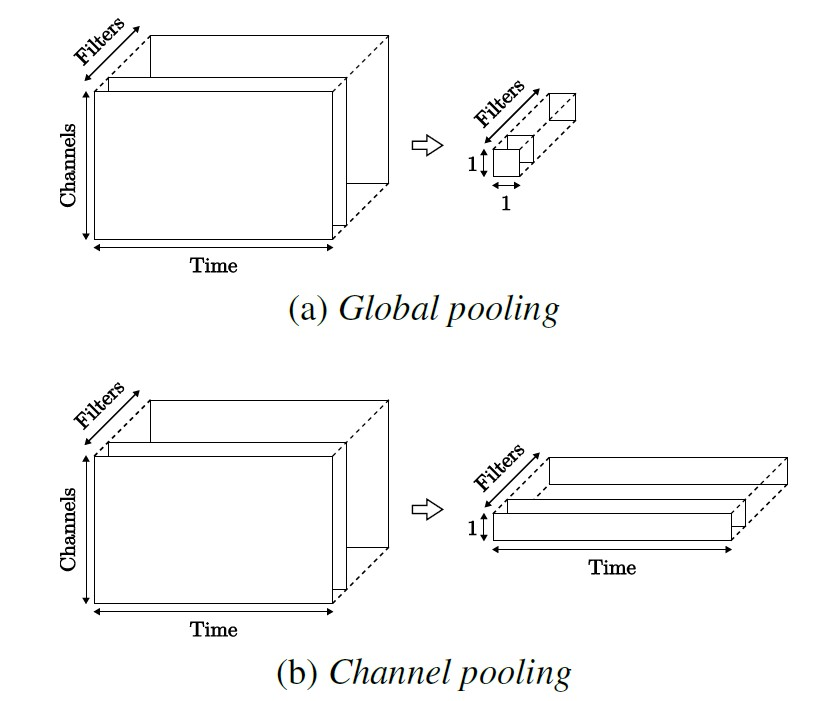

Figura 1.

Ford, Logan & Tang, Hao & Grondin, François & Glass, James. (2019). A Deep Residual Network for Large-Scale Acoustic Scene Analysis. 2568-2572. 10.21437/Interspeech.2019-2731.

### Agrupamiento de promedios por canal
**Agrupamiento de promedios por canal (Channel-wise Mean Pooling)** es una técnica que se utiliza en redes neuronales convolucionales para reducir la dimensionalidad de las activaciones de una capa convolucional al promediar las activaciones a lo largo del eje de los canales.

#### ¿Cómo Funciona?
Supongamos que tienes una activación que proviene de una capa convolucional y tiene la forma `[batch_size, canales, altura, ancho]`, donde:

- **`batch_size`** es el número de imágenes en un lote (batch).
- **`canales`** corresponde al número de mapas de características (feature maps) generados por la capa convolucional.
- **`altura`** y **`ancho`** son las dimensiones espaciales de estos mapas de características.

El **agrupamiento de promedio por canal** toma el promedio de los valores a lo largo del eje de los canales (dimensión `1`). Como resultado, reduce la dimensionalidad de las activaciones a una forma `[batch_size, altura, ancho]`, donde cada valor en la nueva matriz es el promedio de los valores a través de todos los canales en esa posición espacial específica.

#### ¿Para Qué Se Utiliza?
Este método se utiliza principalmente para:

1. **Reducir la Dimensionalidad:** Disminuye la cantidad de datos sin perder la información espacial clave, lo que puede ayudar a reducir la complejidad computacional.
2. **Resumir la Información de los Canales:** Proporciona una vista global de cómo responden todos los canales en cada ubicación espacial de la imagen.

#### Beneficios:
El agrupamiento de promedios por canal es útil en casos donde se necesita una representación compacta de las activaciones sin eliminar la información espacial, pero integrando la información de todos los canales en cada ubicación de la imagen.


In [97]:
def calcular_activaciones_promedio_canal(activaciones):
    """
    Calcula el agrupamiento de promedios por canal para cada capa de una red neuronal.
    Esta función procesa una lista de tensores de activación provenientes de
    diferentes capas de un modelo de red neuronal. Para cada tensor de activación,
    calcula el valor promedio a lo largo de la dimensión del batch (dim=1), lo que
    resulta en un promedio por canal para esa capa específica. Los resultados se
    almacenan en una lista de arreglos NumPy, facilitando su análisis y
    visualización posterior.

    Parámetros:
    - activaciones (List[torch.Tensor]): Lista de tensores de activación obtenidos
                                        de las capas del modelo.

    Returns:
    - activaciones_promedio_canal (List[np.ndarray]): Lista de arreglos donde cada
            arreglo contiene los valores de agrupamiento de promedios por canal
            para la correspondiente capa en la lista de `activaciones`.
    """
    activaciones_promedio_canal = []
    for activacion in activaciones:
        avg_activacion = torch.mean(activacion, dim=1).squeeze().detach().cpu().numpy()
        activaciones_promedio_canal.append(avg_activacion)
    return activaciones_promedio_canal

#### Cálculo de distancia

Podemos usar el agrupamiento de promedios por canal de la imagen semilla y sus versiones transformadas para obtener información acerca de cómo la transformación afecta la representación de la imagen en el espacio de características. Para lograr esto, calculamos la distancia euclidiana entre los dos vectores (las activaciones promedio de las imágenes semilla y sus transformaciones) y normalizamos esta distancia por la distancia entre la imagen semilla y la imagen de control. Esta proporción nos permite comprender el impacto relativo de la transformación en comparación con la línea base establecida por la imagen de control.

In [98]:
def calculo_distancia_promedio_canal(semilla_avg_canal, transformada_avg_canal,
                                     control_avg_canal, capa):
    """
    Calcula la distancia euclidiana entre los vectores resultantes del cálculo de
    agrupamiento de promedios por canal entre la imagen semilla y su transformación,
    normalizando este valor por la distancia euclidiana entre la imagen semilla
    y  la imagen de control.

    Parámetros:
    - semilla_avg_canal: Activaciones promedio de la imagen semilla (2D array).
    - transformada_avg_canal: Activaciones promedio de la imagen transformada (2D array).
    - control_avg_canal: Activaciones promedio de la imagen de control(2D array).
    - capa (str): El número de la capa que se está analizando.

    Returns:
    - distancia_final_canales (float): Distancia promedio por canal.
    """

    # Calculo de distancia Euclidiana
    distancia_imagenes = distance.euclidean(semilla_avg_canal.flatten(),
                                            transformada_avg_canal.flatten())
    distancia_clases = distance.euclidean(semilla_avg_canal.flatten(),
                                          control_avg_canal.flatten())

    # Evitar division por cero
    if distancia_clases == 0:
        print(f"Advertencia: La distancia de control es cero para la capa {capa}. Retornando infinito.")
        return float('inf')

    distancia_final_canales = distancia_imagenes / distancia_clases

    # Imprimir resultados
    print(f"\033[1mUsando el cálculo de agrupamiento de promedios por canal \npara la capa {capa}, la distancia Euclidiana\033[0m")
    print(f"-entre el vector de la imagen y su transformación es: {distancia_imagenes:.3f}")
    print(f"-entre clases de vectores de dos imágenes diferentes es: {distancia_clases:.3f}")
    print(f"-final entre los vectores es: \033[1m{distancia_final_canales:.3f}\033[0m\n")

    return distancia_final_canales

### Agrupamiento de promedios globales (GAP-Global Average Pooling)

#### ¿Qué es el Agrupamiento de promedios globales (GAP)?

**Agrupamiento de promedios globales (GAP-Global Average Pooling)** es una técnica utilizada en redes neuronales convolucionales que reduce una matriz de activaciones (o un tensor de activaciones) a un solo valor promedio por canal, condensando toda la información espacial en un único valor representativo por canal. Esta técnica es especialmente útil en las etapas finales de las redes neuronales, justo antes de las capas de clasificación, ya que ayuda a reducir la dimensionalidad de los datos sin perder información relevante.

#### ¿Cómo Funciona?

Consideremos una activación que proviene de una capa convolucional y tiene la forma `[batch_size, canales, altura, ancho]`, donde:

- **`batch_size`** es el número de imágenes en un lote (batch).
- **`canales`** es el número de mapas de características (feature maps) generados por la capa convolucional.
- **`altura`** y **`ancho`** son las dimensiones espaciales de estos mapas de características.

El **GAP** toma el promedio de los valores a lo largo de las dimensiones espaciales (altura y ancho) y, a menudo, también a lo largo de la dimensión del batch, lo que resulta en un tensor de forma `[canales]`. En otras palabras, por cada canal, se promedian todos los valores dentro de ese canal para generar un solo valor.

#### ¿Para Qué Se Utiliza?

1. **Reducción de Dimensionalidad:** Convierte las activaciones espaciales en un solo valor por canal, lo que reduce significativamente la cantidad de datos, facilitando el uso de las activaciones en capas densas o de clasificación.
2. **Prevención del Sobreajuste (Overfitting):** Al reducir las activaciones a un solo valor por canal, se evita que el modelo dependa demasiado de las posiciones específicas de los objetos en la imagen, lo que puede ayudar a prevenir el sobreajuste.
3. **Interpretabilidad:** Facilita la interpretación del modelo, ya que cada canal se reduce a un valor único que refleja la activación promedio a lo largo de toda la imagen.

#### Beneficio:

El **GAP** es particularmente útil en las etapas finales de una red convolucional, justo antes de la capa de clasificación. Reduce la dimensionalidad de las activaciones y permite que la red se enfoque en la presencia general de características en la imagen, en lugar de su posición exacta. Esto también ayuda a hacer el modelo más robusto y menos susceptible al sobreajuste.

En la imágen a continuación se puede apreciar la transformación para tres canales con alto=6(h) y ancho=6(w).

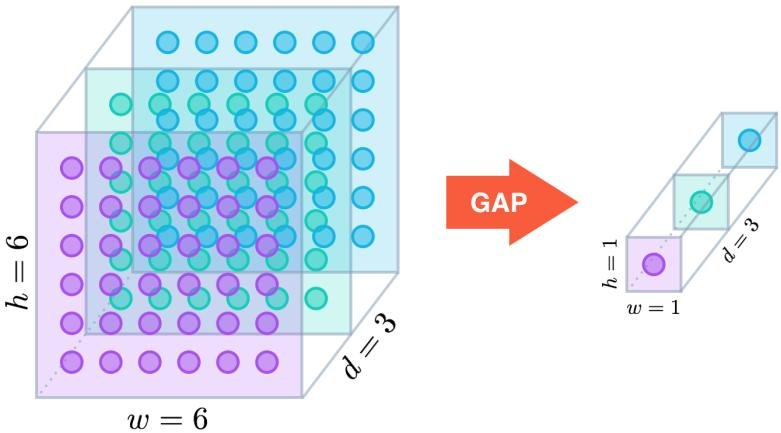

Figura 2.

Shustanov, A & Yakimov, P. (2019). Modification of single-purpose CNN for creating multi-purpose CNN. Journal of Physics: Conference Series. 1368. 052036. 10.1088/1742-6596/1368/5/052036. 

In [99]:
def calcular_activaciones_promedio_gap(activaciones):
    """
    Función que calcula el agrupamiento de promedios globales para las
    activaciones por capa utilizando.

    Esta función reduce las activaciones espaciales de un tensor convolucional a
    un solo valor promedio por canal, condensando la información en una
    representación compacta y fácil de interpretar. Es especialmente útil
    para reducir la dimensionalidad de los datos.

    Parámetros:
    - activaciones (List[torch.Tensor]): Lista de tensores de activación obtenidos
                                        de las capas del modelo.

    Returns:
    - activaciones_promedio_gap (List[np.ndarray]): Lista de arreglos numpy con
                            las activaciones utilizando el GAP para cada capa.
    """
    activaciones_promedio_gap = []
    for activacion in activaciones:
        avg_activacion = torch.mean(activacion, dim=(0, 2, 3)).detach().cpu().numpy()
        activaciones_promedio_gap.append(avg_activacion)
    return activaciones_promedio_gap

#### Cálculo de distancia

Podemos utilizar las activaciones GAP de la imagen semilla y sus transformaciones para obtener información sobre cómo la transformación ha afectado la representación de la imagen en el espacio de características. Para lograr esto, calculamos la distancia euclidiana entre los dos vectores (las activaciones promedio de las imágenes semilla y sus transformaciones), normalizando esta distancia por la distancia entre la imagen semilla y la imagen de control. Esta proporción nos permite entender el impacto relativo de la transformación en comparación con la línea base establecida por la imagen de control.

In [100]:
def calculo_distancia_gap(semilla_avg_gap, transformada_avg_gap,control_avg_gap,
                          capa):
    """
    Calcula la proporción de la distancia entre las imágenes semilla y transformada
    respecto a la distancia entre la imagen semilla y la imagen de control.

    Calcula la distancia euclidiana entre los vectores de activación calculados
    con el GAP entre la imagen semilla y su transformación, normalizando este
    valor por la distancia euclidiana entre la imagen semilla y  la imagen de
    control.

    Parámetros:
    - semilla_avg_gap: Activación promedio GAP para la imagen semilla (matriz 2D).
    - transformada_avg_gap: Activación promedio GAP para la imagen transformada (matriz 2D).
    - control_avg_gap: Activación promedio GAP para la imagen de control (matriz 2D).
    - capa (str): El nombre de la capa que se está analizando.

    Retorna:
    - distancia_final_gap (float): La proporción de la distancia entre las
        imágenes semilla y transformada respecto a la distancia entre las
        imágenes semilla y de control.
    """

    # Calculo de distancias Euclidianas
    distancia_imagenes = distance.euclidean(semilla_avg_gap.flatten(),
                                            transformada_avg_gap.flatten())
    distancia_clases = distance.euclidean(semilla_avg_gap.flatten(),
                                          control_avg_gap.flatten())

    # Evitar división por cero
    if distancia_clases == 0:
        print(f"""Advertencia: La distancia de control es cero para la capa
                {capa}. Retornando infinito.""")
        return float('inf')

    distancia_final_gap = distancia_imagenes / distancia_clases

    # Imprimir resultados
    print(f"\033[1mUsando la activación GAP \npara la capa {capa}, la distancia Euclidiana\033[0m")
    print(f"""-entre los vectores de una imagen y su transformación es: {distancia_imagenes:.3f}""")
    print(f"""-entre clases de los vectores de dos imágenes distintas es: {distancia_clases:.3f}""")
    print(f"""-final entre los vectores usando activaciones GAP es: \033[1m{distancia_final_gap:.3f}\033[0m\n""")

    return distancia_final_gap

### Cálculo de Selectividad

Para cuantificar la selectividad, utilizamos un métodos estadístico no paramétrico definido por la siguiente fórmula:

$S = \frac{1-\frac{(\frac{1}{n}\sum_{1}^{n}r_i)^{2}}{\frac{1}{n}\sum_{1}^{n}r_i^{2}}}{1-\frac{1}{n}}$ [[3]](#3)

donde:
$r_i$ : es la respuesta (o activación) de una neurona (o mapa de características) a cada estímulo.

$n$ : Número de respuestas (transformaciones o estímulos) utilizadas para evaluar la selectividad.

La fórmula mide cuán activa es una neurona (o mapa de características) a lo largo de una variedad de estímulos. Un valor de selectividad más cercano a 1 indica que la neurona responde de manera selectiva sólo a unos pocos estímulos.

Para proporcionar cierta intuición, la medida evalúa la proporción de la tasa de disparo media cuadrada total al promedio de los promedios al cuadrado, y S invierte la métrica de modo que las neuronas que responden a una fracción menor de imágenes producen medidas de selectividad más altas.

Por ejemplo, si una neurona responde a todas las imágenes con tasas de disparo aproximadamente iguales, el numerador y el denominador serán casi iguales, resultando en 1 (y S de 0). Para una neurona que responde solo a una imagen, el promedio de promedios al cuadrado (el denominador) excederá la baja tasa media de disparo (el numerador), resultando en S de 1. [[4]](#4)

In [101]:
def calculo_selectividad(activaciones):
    """
    Calcula la selectividad de las activaciones para cada mapa de características.

    La selectividad mide qué tan selectivamente responden las neuronas a los
    estímulos.
    Cuantifica si las activaciones están distribuidas uniformemente o concentradas
    en unas pocas respuestas. La fórmula utilizada se basa en la definición de
    Willmore y Tolhurst:
    Fórmula: S = (1 - (respuesta_promedio^2 / respuesta_promedio_cuadrada)) / (1 - 1/n)
    """

    n = activaciones.shape[1]  # Número de estímulos o transformaciones.

    # Promedio de activación para cada mapa de características.
    respuesta_promedio = np.mean(activaciones, axis=1)
    # Promedio de los cuadrados de las activaciones para cada mapa de características.
    respuesta_promedio_cuadrada = np.mean(activaciones**2, axis=1)

    # Calcula la selectividad para cada mapa de características.
    valores_selectividad = np.where(respuesta_promedio_cuadrada != 0,
                                  (1 - (respuesta_promedio**2 / 
                                        respuesta_promedio_cuadrada)) / (1 - 1/n),
                                  0)

    return valores_selectividad

In [102]:
def computar_selectividad_para_activaciones(capa, activaciones):
    """
    Cambia el tamaño del vector de las activaciones y calcula la selectividad, retornando los resultados.
    """
    activaciones_reshaped = activaciones.view(activaciones.size(0), -1).cpu().detach().numpy()
    selectividad = calculo_selectividad(activaciones_reshaped)
    return capa, selectividad

## Análisis a través de visualizaciones

Visualizamos mediante gráficos las activaciones del modelo en varias capas para obtener información sobre su comportamiento y rendimiento. De estas activaciones destacamos dos aspectos clave que incluyen:

1. **Mapas de características y cálculo promedio de activaciones**: utilizando la función plot_mapas_and_avg_activaciones, analizamos las activaciones promedio en diferentes capas para varias imágenes de entrada. En esta tarea, comparamos qué ocurre entre la imagen semilla y sus transformaciones, visualizando los promedios de los cálculos de Agrupamiento de promedios por canal y GAP en cada paso. En general, esto nos ayuda a comprender cómo responde el modelo a diferentes transformaciones, qué sucede en cada capa seleccionada y qué tan bien captura el modelo las características relevantes de los datos de entrada (invarianza).
2. **Análisis de selectividad**: la función plot_selectividad complementa este análisis al proporcionar histogramas de las activaciones de cada capa. Permitiéndonos evaluar la dispersión de las activaciones en cada capa,  indicándonos cuántas neuronas se activan en respuesta a las entradas. Un mayor grado de dispersión puede sugerir que el modelo está filtrando eficazmente el ruido y centrándose en las características más destacadas.

En conjunto, estas visualizaciones nos permiten entender con mayor profundidad qué ocurre con la invarianza y la selectividad en cada capa seleccionada. Ayudándonos a comprender mejor cómo se obtiene el resultado final. Permitiéndonos explorar tanto lo valioso de las representaciones como la eficiencia de las activaciones de la red en las capas. La definición de los siguientes gráficos ilustran estos conocimientos.

### Selectividad

In [103]:
def plot_selectividad(activaciones, capas):
    """
    Función para obtener una primera intuición sobre la selectividad, usando
    los histogramas de las activaciones.
    """
    fig, axes = plt.subplots(1, len(activaciones), figsize=(15, 5))
    for i, activacion in enumerate(activaciones):
        # Aplana todas las activaciones de la capa actual
        activaciones_flat = activacion.flatten().detach().cpu().numpy()
        axes[i].hist(activaciones_flat, bins=50, color='blue', alpha=0.7)
        axes[i].set_title(f'Capa {capas[i]}')
        axes[i].set_yscale('log')  # Usamos la escala logaritmica para una mejor visualizacion
    plt.tight_layout()
    plt.show()

### Invarianza

In [104]:
def plot_avg_canal(axes, x, capa_idx, semilla_canal, transformada_canal, control_canal):
    """Graficar agrupamiento de promedios por canal para una capa determinada"""

    axes[x, 0].imshow(semilla_canal, cmap='viridis', aspect='auto')
    axes[x, 0].set_title(f'Capa {capa_idx}\nAgrupamiento de promedios por canal \nImagen Semilla')

    axes[x, 1].imshow(transformada_canal, cmap='viridis', aspect='auto')
    axes[x, 1].set_title(f'Capa {capa_idx} \nAgrupamiento de promedios por cana \nImagen Transformada')

    axes[x, 2].imshow(control_canal, cmap='viridis', aspect='auto')
    axes[x, 2].set_title(f'Capa {capa_idx}\nAgrupamiento de promedios por cana \nImagen Control')

In [105]:
def plot_hist_avg_canal(axes, x, capa_idx, semilla_canal, transformada_canal,
                        control_canal):
    """Gráfica histograma de agrupamiento de promedios por canal para una capa
    determinada."""

    xmin = min(semilla_canal.min(), transformada_canal.min(), control_canal.min())
    xmax = max(semilla_canal.max(), transformada_canal.max(), control_canal.max())

    axes[x, 0].hist(semilla_canal, bins=50, color='blue', alpha=0.7)
    axes[x, 0].set_yscale('log')
    axes[x, 0].set_xlim([xmin, xmax])
    axes[x, 0].set_title(f'Capa {capa_idx} \nHistograma de Activaciones \nAgrupamiento de promedios por canal\nImagen Semilla')

    axes[x, 1].hist(transformada_canal, bins=50, color='blue', alpha=0.7)
    axes[x, 0].set_yscale('log')
    axes[x, 0].set_xlim([xmin, xmax])
    axes[x, 1].set_title(f'Capa {capa_idx} \nHistograma de Activaciones \nAgrupamiento de promedios por canal \nImagen Transformada')

    axes[x, 2].hist(control_canal, bins=50, color='blue', alpha=0.7)
    axes[x, 0].set_yscale('log')
    axes[x, 0].set_xlim([xmin, xmax])
    axes[x, 2].set_title(f'Capa {capa_idx} \nHistograma de Activaciones \nAgrupamiento de promedios por canal \nImagen Control')

In [106]:
def plot_gap(axes, x, capa_idx, semilla_gap, transformada_gap, control_gap):
    """Gráfica activaciones calculadas con el GAP para una capa determinada."""

    ymin = min(semilla_gap.min(), transformada_gap.min(), control_gap.min())
    ymax = max(semilla_gap.max(), transformada_gap.max(), control_gap.max())

    axes[x, 0].plot(semilla_gap)
    axes[x, 0].set_ylim([ymin, ymax])
    axes[x, 0].set_title(f'Capa {capa_idx} \nGAP Activaciones promedio \nImagen Semilla')

    axes[x, 1].plot(transformada_gap)
    axes[x, 1].set_ylim([ymin, ymax])
    axes[x, 1].set_title(f'Capa {capa_idx} \nGAP Activaciones promedio \nImagen Transformada')

    axes[x, 2].plot(control_gap)
    axes[x, 2].set_ylim([ymin, ymax])
    axes[x, 2].set_title(f'Capa {capa_idx} \nGAP Activaciones promedio \nImagen Control')

In [107]:
def plot_mapas_avg_activaciones(
        semilla_avg_canal,
        transformada_avg_canal,
        crtl_avg_canal,
        semilla_gap,
        transformada_gap,
        crtl_gap,
        capas):
    """
    Visualización de activaciones por agrupamiento de promedios por canal y
    activaciones por GAP.

    Parámetros:
    - semilla_avg_canal: Agrupamiento de promedios por canal para la imagen semilla.
    - transformada_avg_canal: Agrupamiento de promedios por canal para la imagen
                        transformada.
    - crtl_avg_canal: Agrupamiento de promedios por canal para la imagen de control.
    - semilla_gap: GAP para la imagen semilla.
    - transformada_gap: GAP para la imagen transformada.
    - crtl_gap: GAP para la imagen de control.
    - capas: Lista de capas a visualizar.

    Returns:
    - distancia_gap_por_capa: Distancia calculada para cada capa usando el
                                cálculo GAP.
    - distancia_canal_por_capa: Distancia calculada para cada capa usando el
                                cálculo de agrupamiento de promedios por canal.
    """
    num_capas = len(capas)
    fig, axes = plt.subplots(num_capas * 3, 3, figsize=(10, 8 * num_capas))

    distancia_gap_por_capa = []
    distancia_canal_por_capa = []

    for i in range(num_capas):
        #############################################
        # Fila 1: Agrupamiento de promedios por canal
        #############################################

        plot_avg_canal(
            axes,
            i * 3,
            i,
            semilla_avg_canal[i],
            transformada_avg_canal[i],
            crtl_avg_canal[i])

        ##############################################################
        # Fila 2: Histograma con Agrupamiento de promedios por canal #
        ##############################################################

        plot_hist_avg_canal(
            axes,
            i * 3 + 1,
            i,
            semilla_avg_canal[i].flatten(),
            transformada_avg_canal[i].flatten(),
            crtl_avg_canal[i].flatten())

        ##################################################
        # Fila 3: Agrupamiento de promedios globales GAP #
        ##################################################

        plot_gap(
            axes,
            i * 3 + 2,
            i,
            semilla_gap[i],
            transformada_gap[i],
            crtl_gap[i])

        ##########################################################################
        # Cálculo de distancia entre dos vectores de activaciones para cada capa #
        ##########################################################################
        # Cálculo de Distancia para GAP #
        distancia_gap = calculo_distancia_gap(
            semilla_gap[i],
            transformada_gap[i],
            crtl_gap[i],
            capas[i])
        distancia_gap_por_capa.append(distancia_gap)

        # Cálculo de distancia para agrupamiento de promedios por canal #
        distancia_avg_canal = calculo_distancia_promedio_canal(
            semilla_avg_canal[i],
            transformada_avg_canal[i],
            crtl_avg_canal[i],
            capas[i])
        distancia_canal_por_capa.append(distancia_avg_canal)

    plt.tight_layout(pad=4.0)
    plt.show()
    plt.figure(figsize=(10, 6))
    plt.plot(capas, distancia_gap_por_capa, marker='o', linestyle='-', color='b', label='Distancia GAP')
    plt.plot(capas, distancia_canal_por_capa, marker='s', linestyle='--', color='r', label='Distancia Agrupamiento de promedios por canal')
    plt.xlabel('Capa')
    plt.ylabel('Distancia Final')
    plt.title('Distancia Final entre los vectores de activación')
    plt.legend()
    plt.grid(True)
    plt.show()

    return distancia_gap_por_capa, distancia_canal_por_capa

# Ejecución del proyecto

## Carga de imagénes

In [108]:
# Imagen original a ser utilizada como semilla
imagen_original = '../images/squirrel.png'

In [109]:
# Control image
imagen_control = '../images/termo.png'

## Generación de set de datos

In [110]:
# Transformacion de imagen original
procesar_imagen(imagen_original, desplazamiento=250, rotacion=30, factor_escala1=0.5, factor_escala2=1.5)

Características de la imagen original: 
Ancho: 2048
            Alto: 1536 
Modo: RGB Formato: PNG
            
Tipo: <class 'PIL.PngImagePlugin.PngImageFile'>

Características del objeto: 
Ancho: 2048
            Alto: 1536 
Modo: RGBA Formato: None
            
Tipo: <class 'PIL.Image.Image'>


In [111]:
# Lista de imagenes transformadas
imagen_semilla = "objeto_semilla.png"

imagenes_transformadas_lista = [
    "objeto_desplazado_derecha.png", "objeto_desplazado_izquierda.png",
    "objeto_rotado_derecha.png", "objeto_rotado_izquierda.png",
    "objeto_escala05.png", "objeto_escala1_5.png",
    "objeto_con_contexto.png"
]

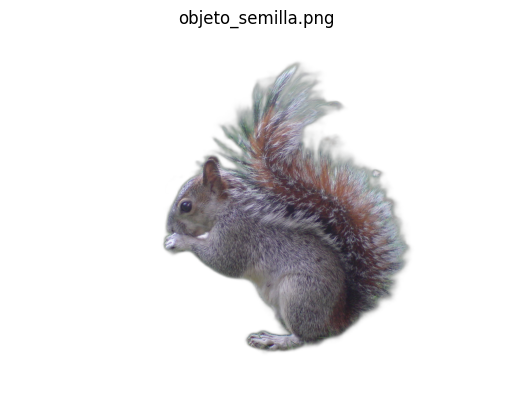

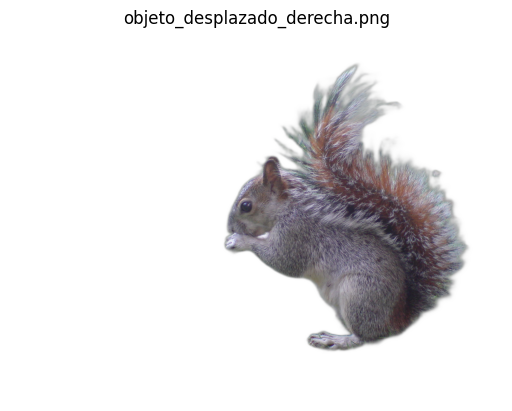

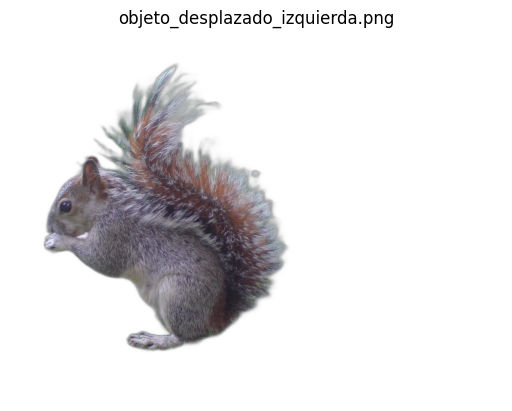

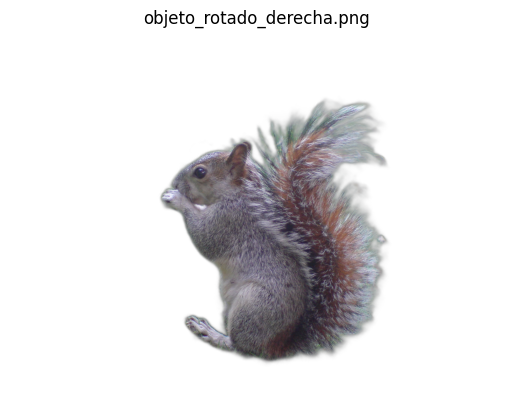

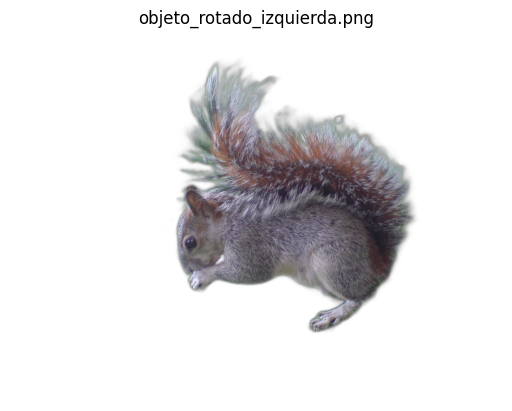

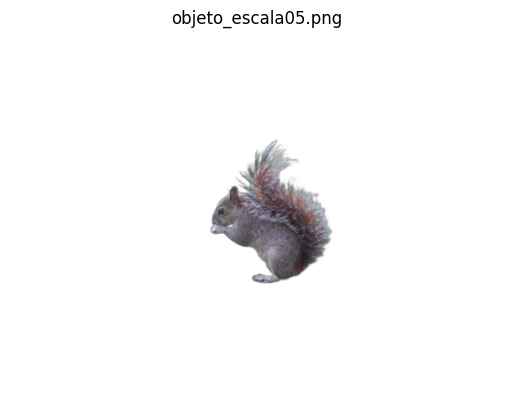

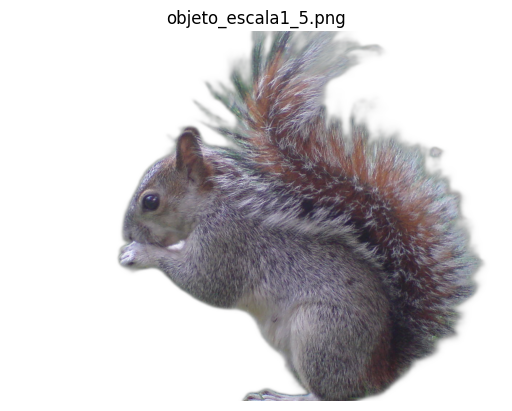

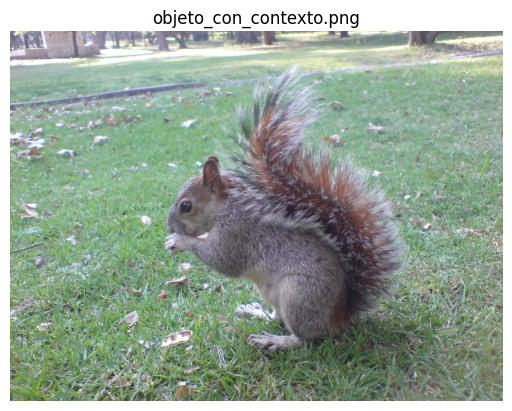

In [112]:
# Muestra de imágenes transformadas
mostrar_imagen(imagen_semilla)

for img in imagenes_transformadas_lista:
    mostrar_imagen(img)

## Imágenes a tensor

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


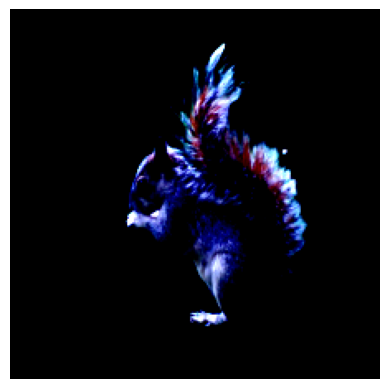

In [113]:
# Imagen semilla
ruta_imagen_semilla="../images/imagenesTransformadas"
semilla_tensor = tensor_transformacion_imagen(os.path.join(ruta_imagen_semilla, imagen_semilla))

plt.imshow(semilla_tensor.squeeze(0).permute(1, 2, 0).numpy())
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


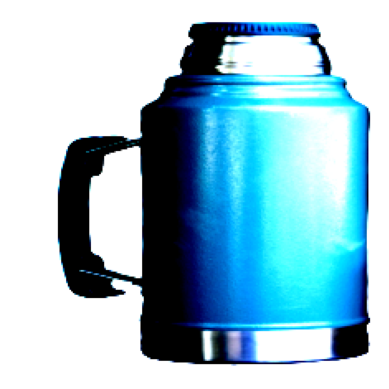

In [114]:
# Imagen control
control_tensor = tensor_transformacion_imagen(imagen_control)

plt.imshow(control_tensor.squeeze(0).permute(1, 2, 0).numpy())
plt.axis('off')
plt.show()

In [115]:
# Guarda los tensores de las transformaciones de la imagen
images_transformadas_tensores = []
transform_img_ruta = "../images/imagenesTransformadas"

for imagen_transformada in imagenes_transformadas_lista:

    imagen_ruta_completa = os.path.join(transform_img_ruta, imagen_transformada)

    img_tensor = tensor_transformacion_imagen(imagen_ruta_completa)

    # Agregar el tensor resultante a la lista
    images_transformadas_tensores.append(img_tensor)

## Análisis de Invarianza

En esta sección, analizaremos la invariancia del modelo capa por capa, transformación por transformación. Este análisis tiene como objetivo proporcionar información sobre cómo las representaciones de características del modelo cambian (o se mantienen constantes) a lo largo de diferentes transformaciones de las imágenes de entrada. Los hallazgos de este análisis se evaluarán más a fondo en el contexto del proyecto en general.

In [116]:
# Estas listas se inicializan para almacenar las distancias de cada capa de las diferentes imágenes procesadas.
gap_distancia_por_capa, avg_canal_distancias_por_capa = [], []
gap_distancias_lista_completa = []
avg_canal_distancias_lista_completa = []

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_desplazado_derecha.png


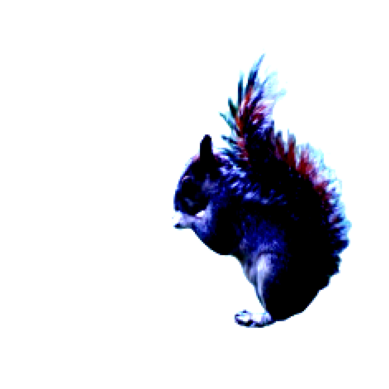

Usando la activación GAP 
para la capa 12, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 7.225
-entre clases de los vectores de dos imágenes distintas es: 10.844
-final entre los vectores usando activaciones GAP es: 0.666

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 12, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 6.307
-entre clases de vectores de dos imágenes diferentes es: 10.553
-final entre los vectores es: 0.598

Usando la activación GAP 
para la capa 14, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 4.409
-entre clases de los vectores de dos imágenes distintas es: 6.671
-final entre los vectores usando activaciones GAP es: 0.661

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 14, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 3.794
-entre clases de vectores de dos imágenes diferentes es: 5.732
-

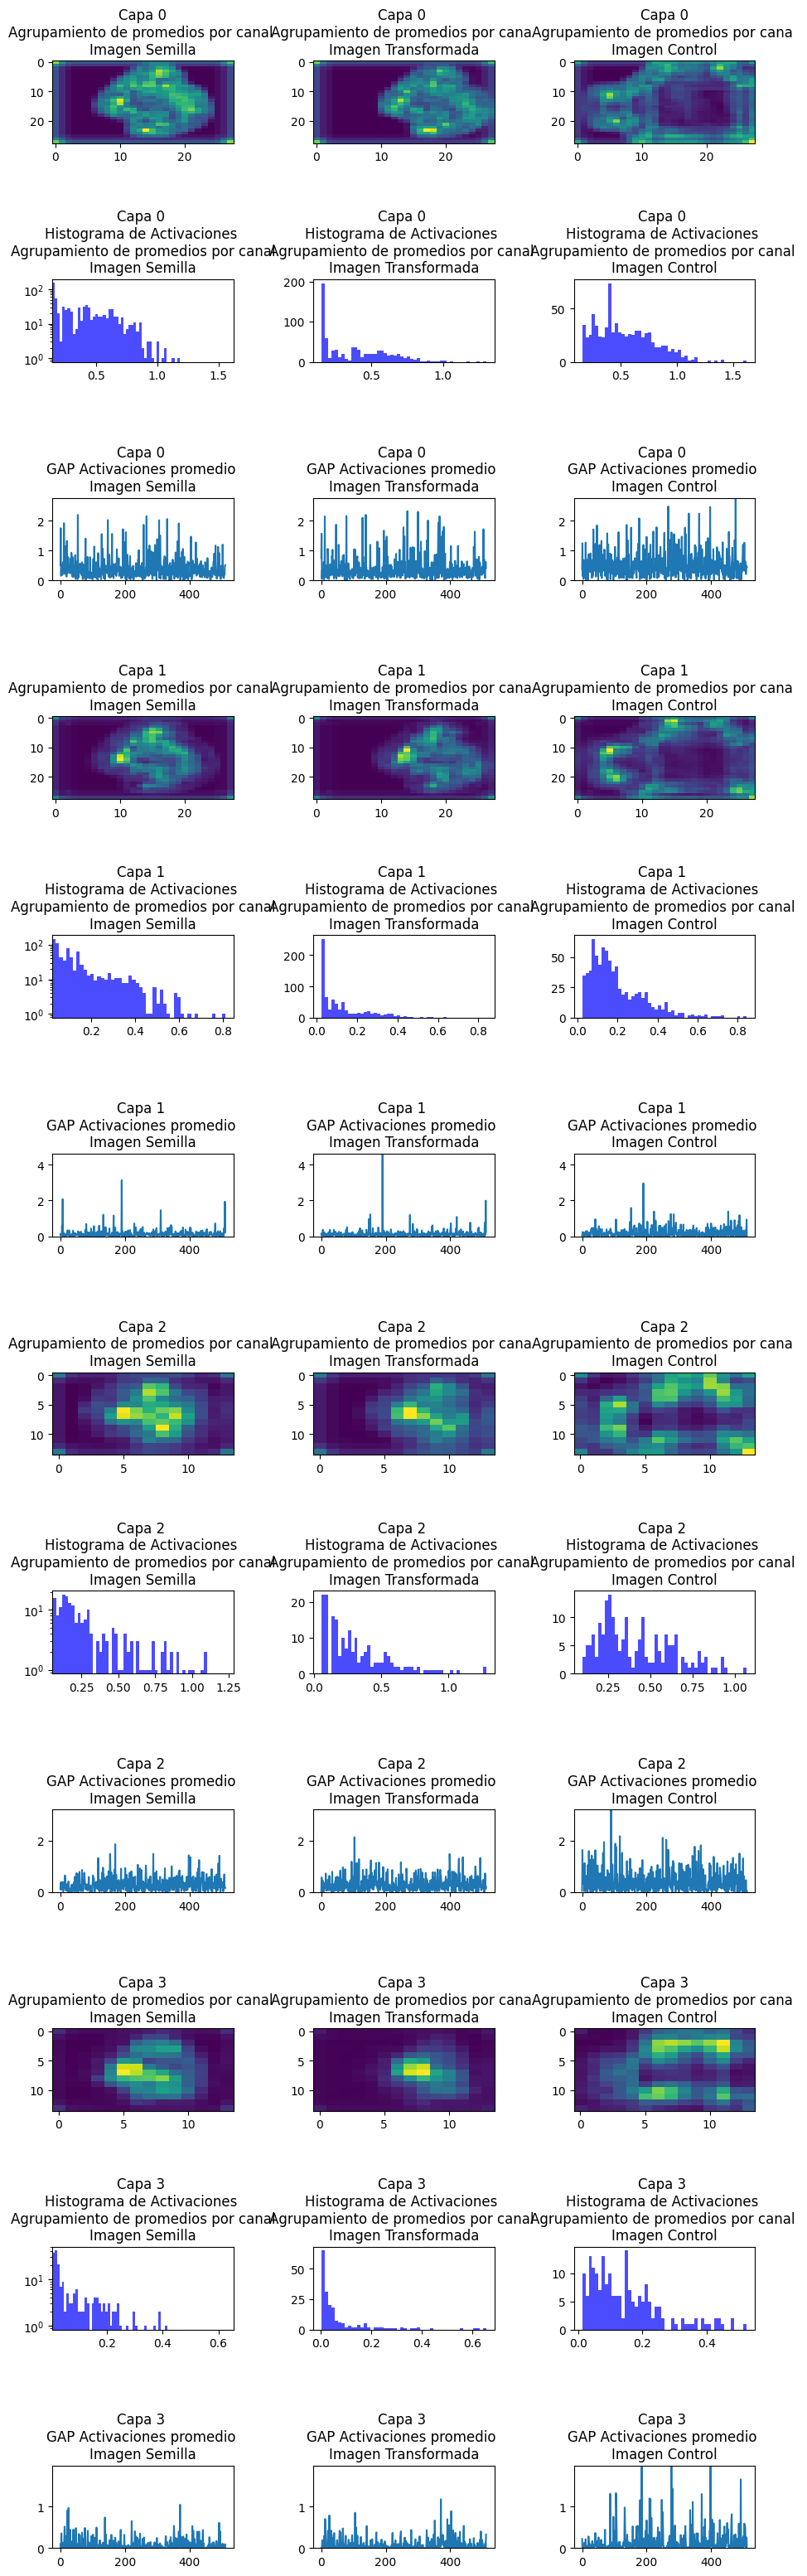

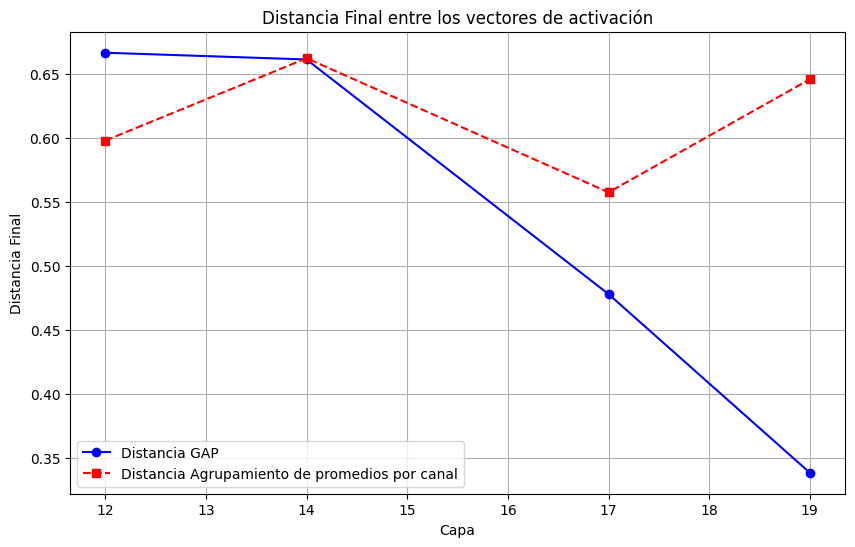

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_desplazado_izquierda.png


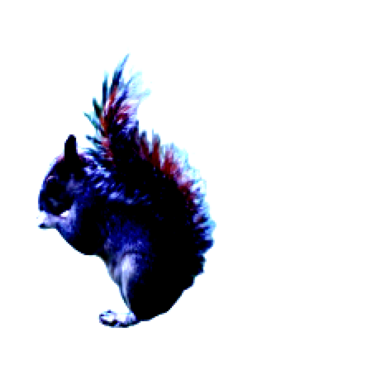

Usando la activación GAP 
para la capa 12, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 7.248
-entre clases de los vectores de dos imágenes distintas es: 10.844
-final entre los vectores usando activaciones GAP es: 0.668

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 12, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 9.526
-entre clases de vectores de dos imágenes diferentes es: 10.553
-final entre los vectores es: 0.903

Usando la activación GAP 
para la capa 14, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 4.410
-entre clases de los vectores de dos imágenes distintas es: 6.671
-final entre los vectores usando activaciones GAP es: 0.661

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 14, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 5.463
-entre clases de vectores de dos imágenes diferentes es: 5.732
-

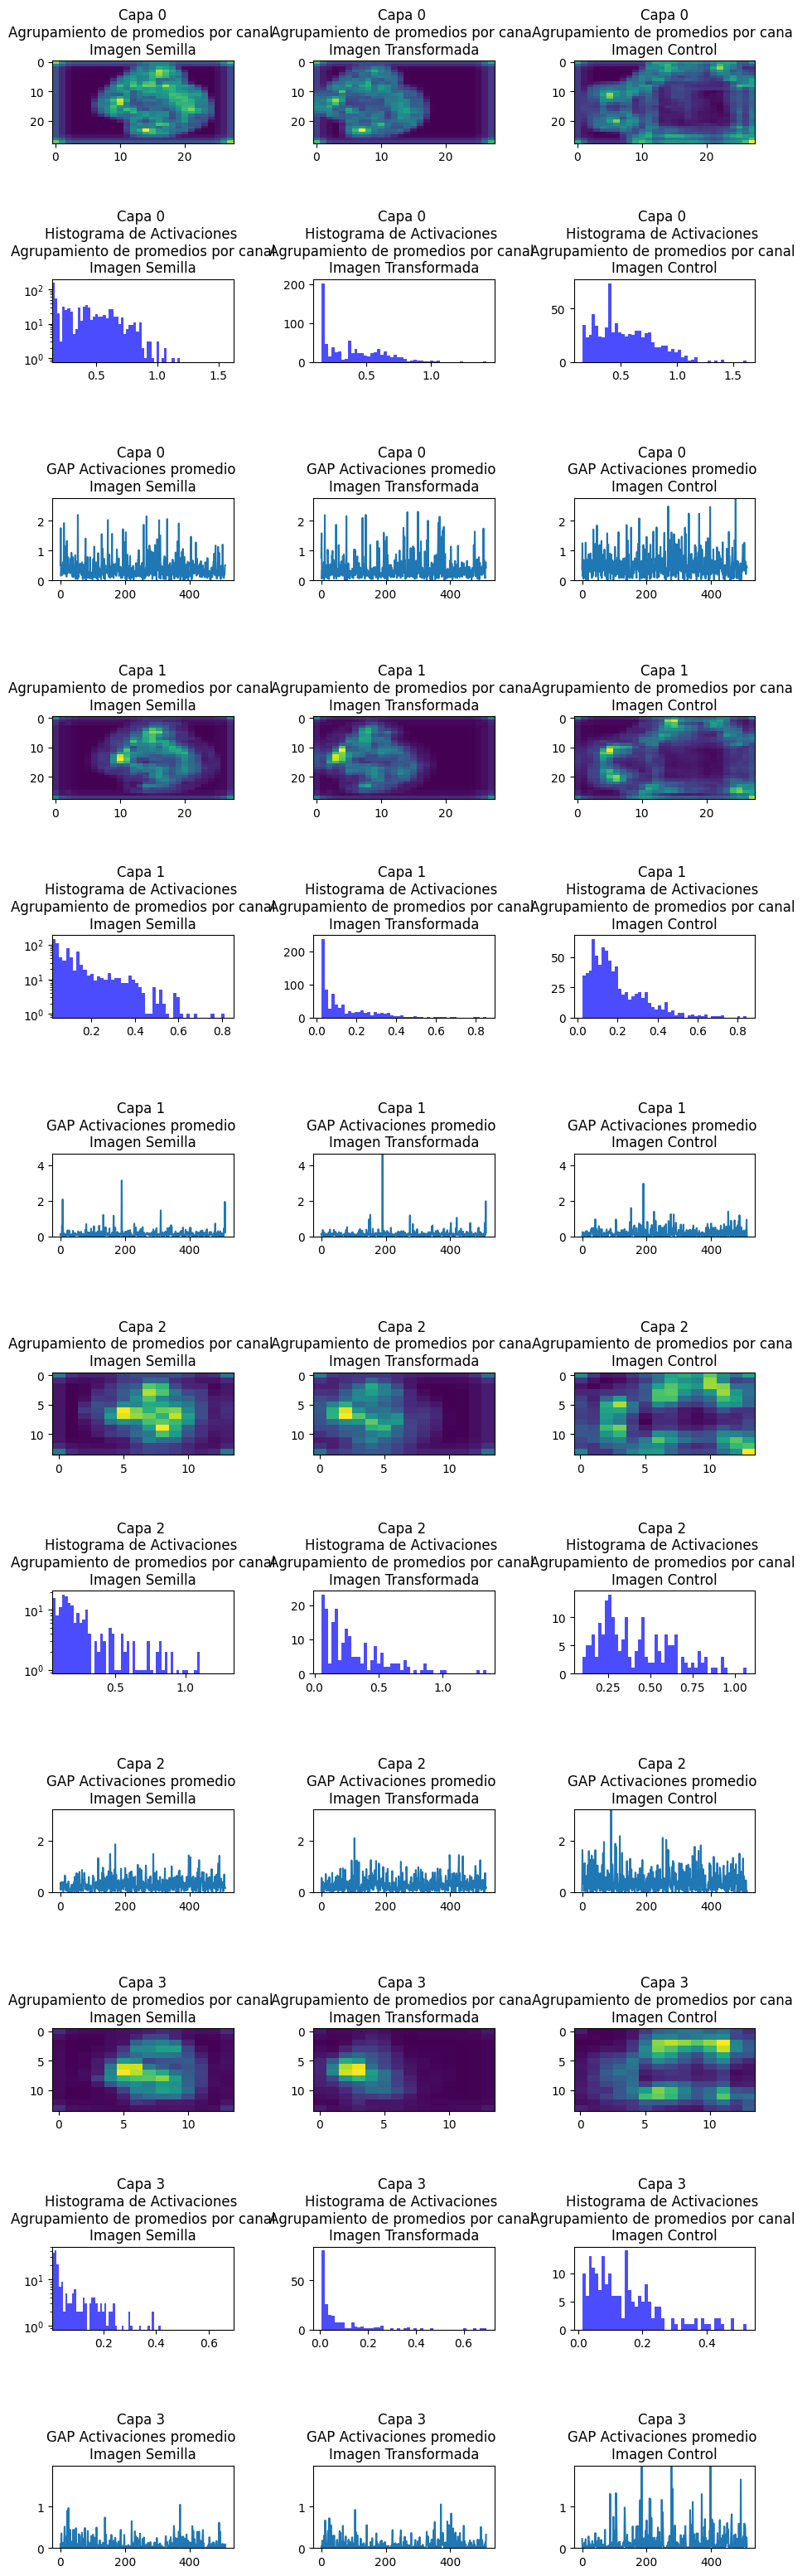

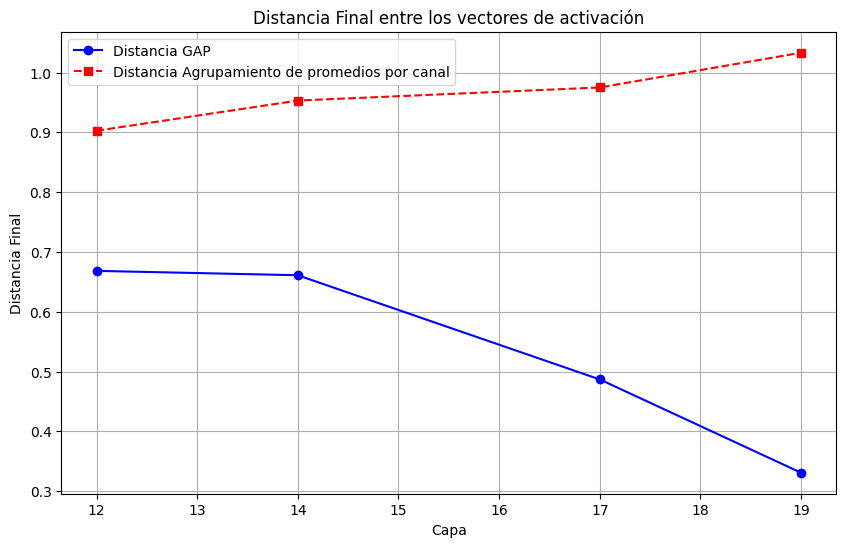

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_rotado_derecha.png


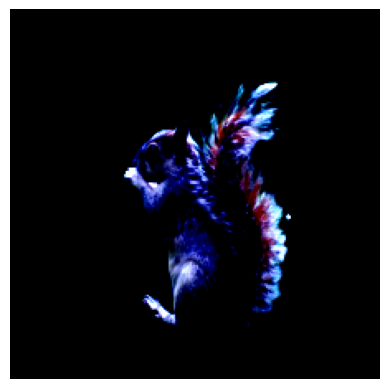

Usando la activación GAP 
para la capa 12, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 1.301
-entre clases de los vectores de dos imágenes distintas es: 10.844
-final entre los vectores usando activaciones GAP es: 0.120

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 12, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 4.577
-entre clases de vectores de dos imágenes diferentes es: 10.553
-final entre los vectores es: 0.434

Usando la activación GAP 
para la capa 14, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 1.084
-entre clases de los vectores de dos imágenes distintas es: 6.671
-final entre los vectores usando activaciones GAP es: 0.163

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 14, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 2.914
-entre clases de vectores de dos imágenes diferentes es: 5.732
-

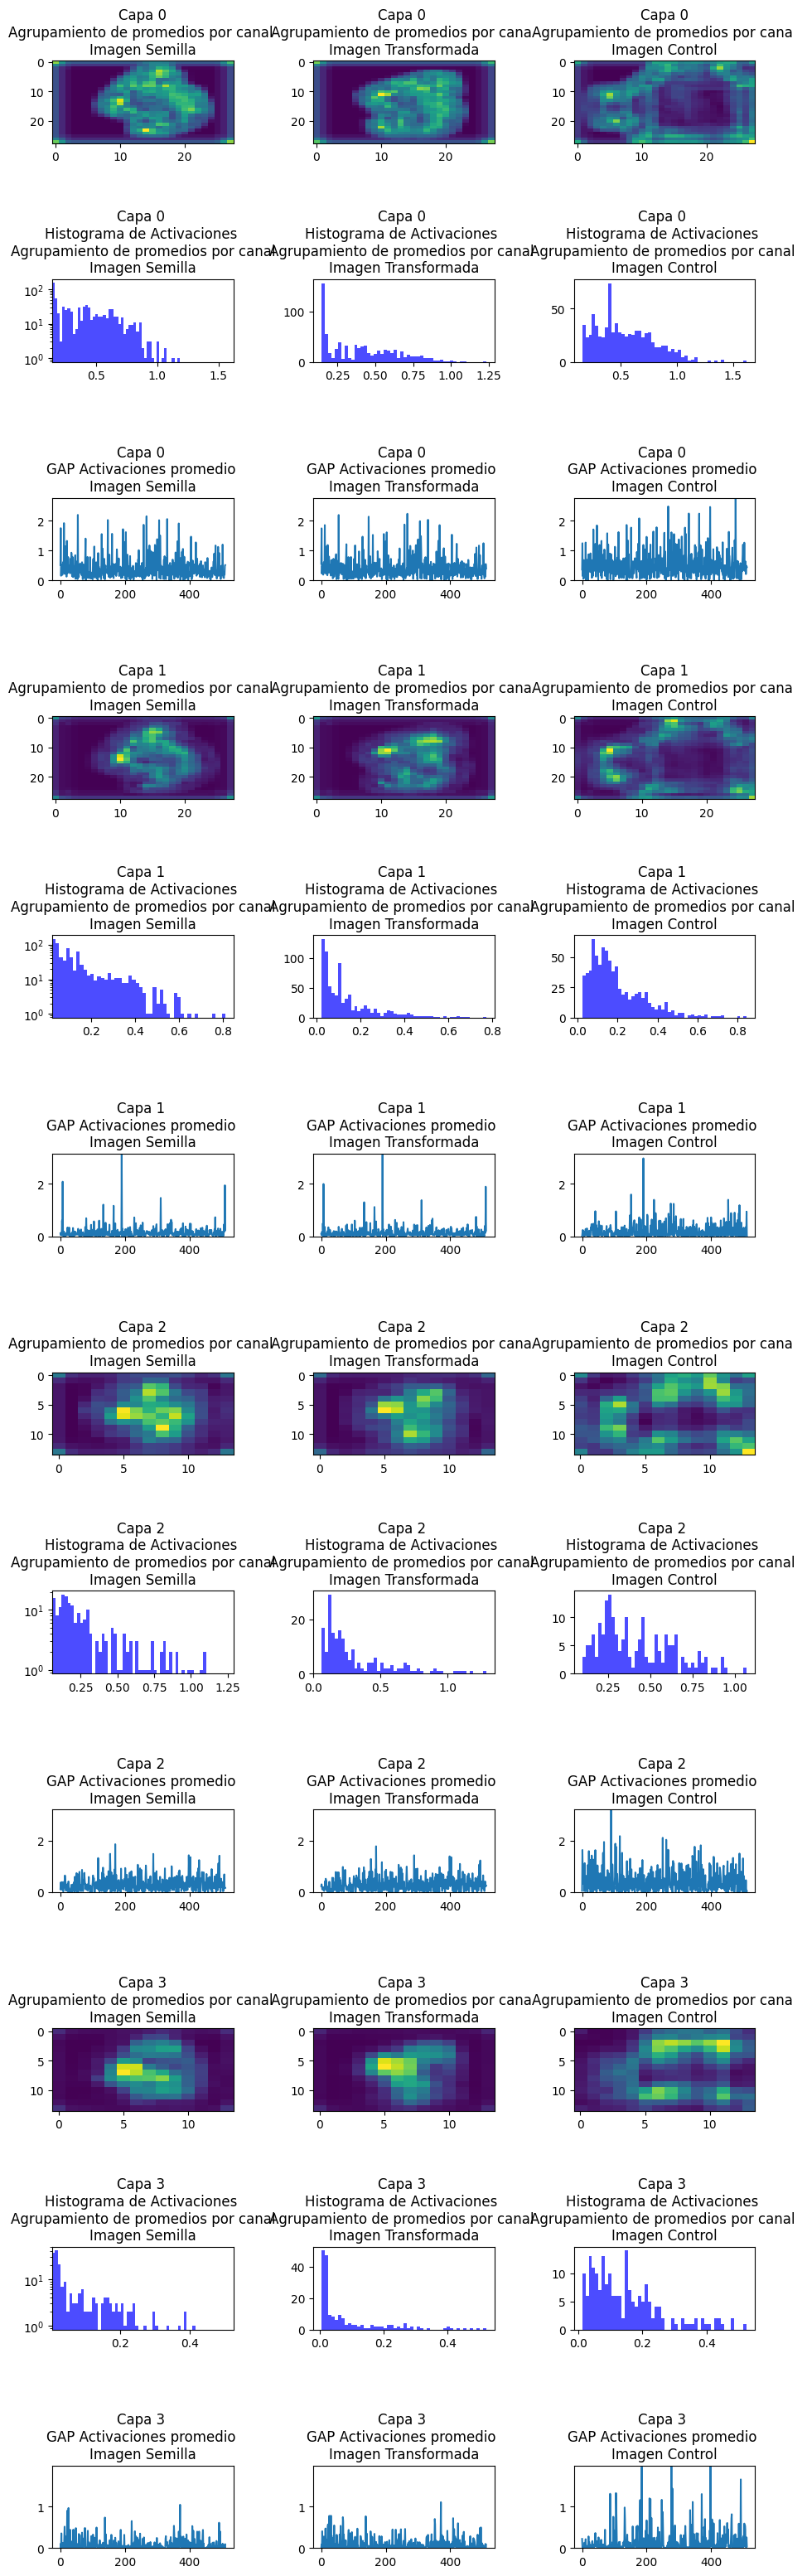

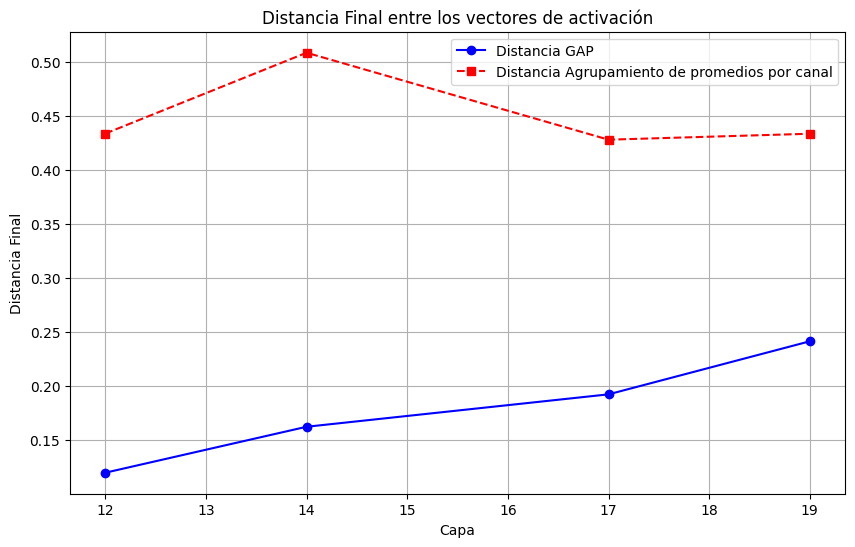

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_rotado_izquierda.png


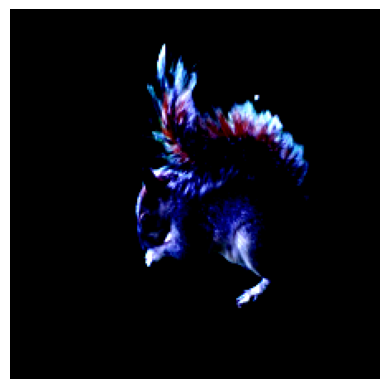

Usando la activación GAP 
para la capa 12, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 1.279
-entre clases de los vectores de dos imágenes distintas es: 10.844
-final entre los vectores usando activaciones GAP es: 0.118

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 12, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 4.617
-entre clases de vectores de dos imágenes diferentes es: 10.553
-final entre los vectores es: 0.437

Usando la activación GAP 
para la capa 14, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 0.988
-entre clases de los vectores de dos imágenes distintas es: 6.671
-final entre los vectores usando activaciones GAP es: 0.148

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 14, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 2.757
-entre clases de vectores de dos imágenes diferentes es: 5.732
-

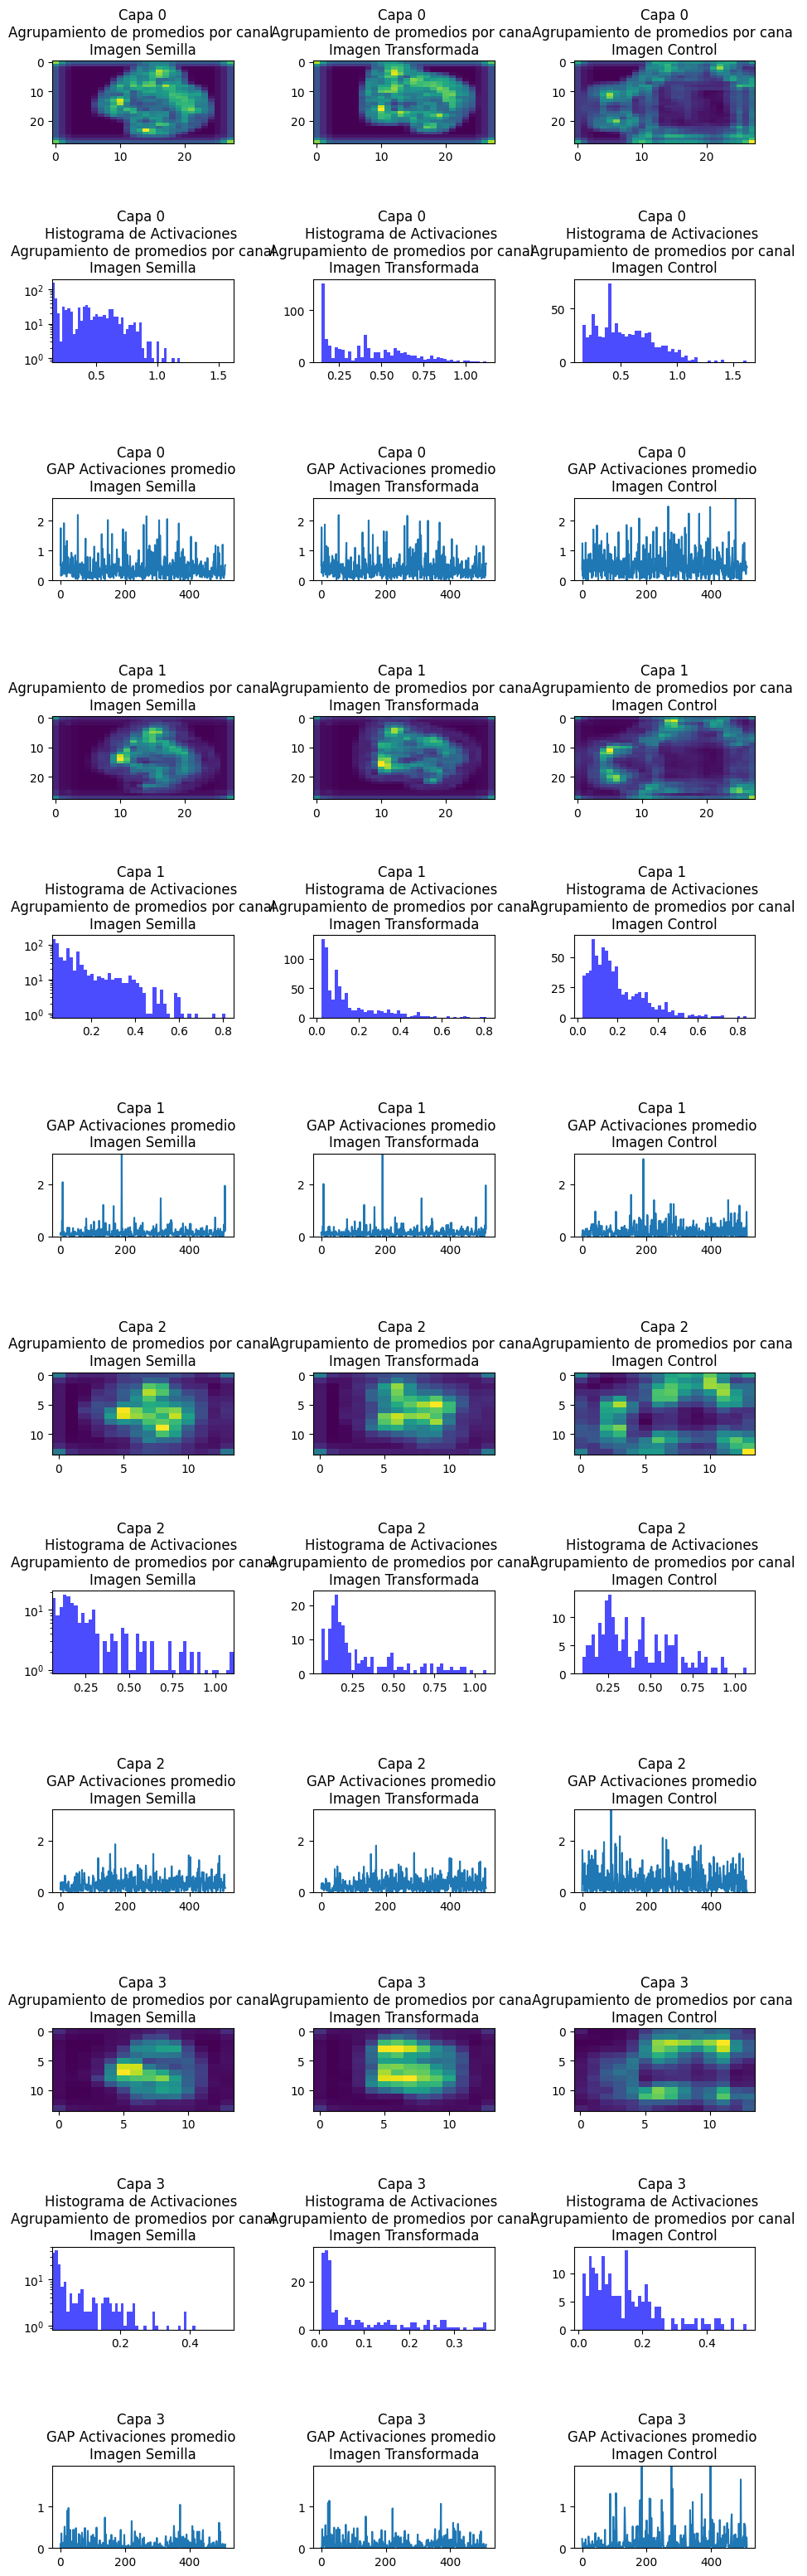

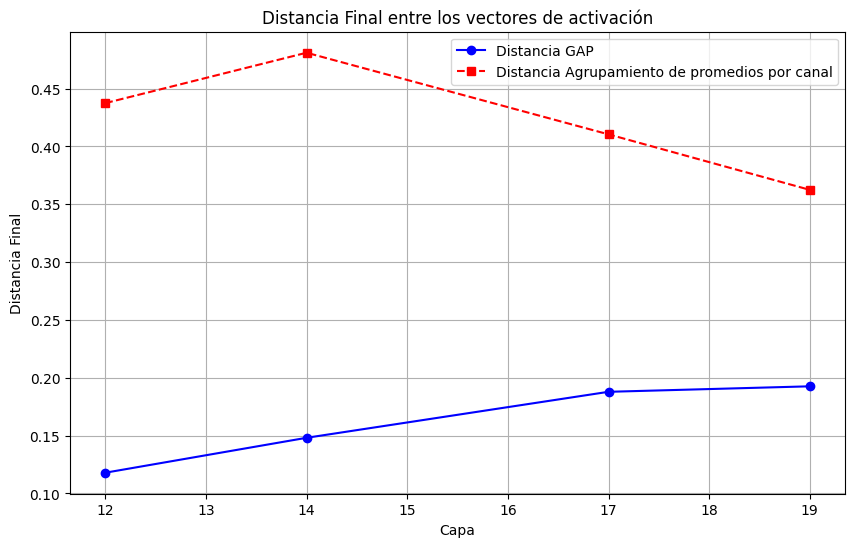

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_escala05.png


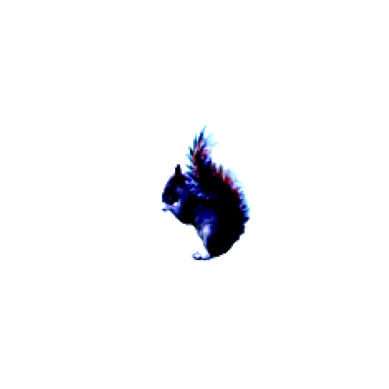

Usando la activación GAP 
para la capa 12, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 8.549
-entre clases de los vectores de dos imágenes distintas es: 10.844
-final entre los vectores usando activaciones GAP es: 0.788

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 12, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 7.150
-entre clases de vectores de dos imágenes diferentes es: 10.553
-final entre los vectores es: 0.677

Usando la activación GAP 
para la capa 14, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 5.138
-entre clases de los vectores de dos imágenes distintas es: 6.671
-final entre los vectores usando activaciones GAP es: 0.770

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 14, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 3.923
-entre clases de vectores de dos imágenes diferentes es: 5.732
-

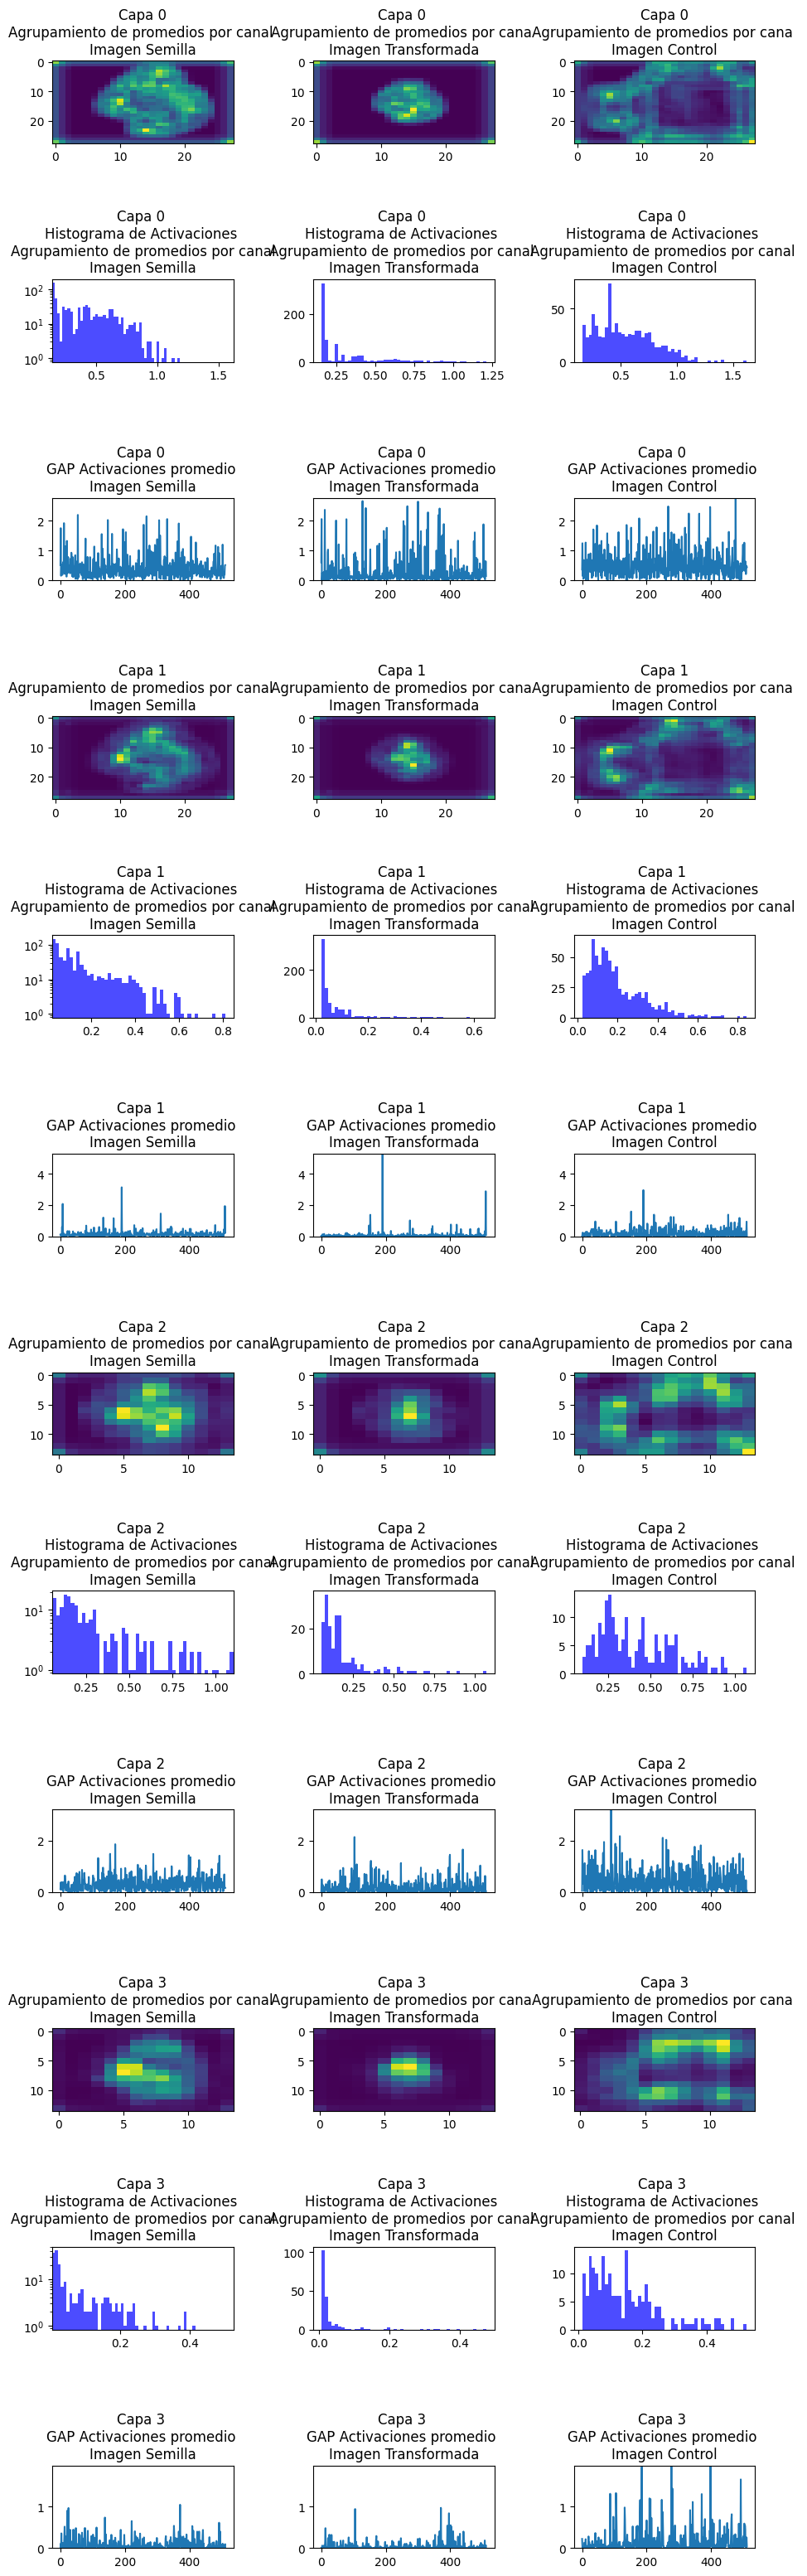

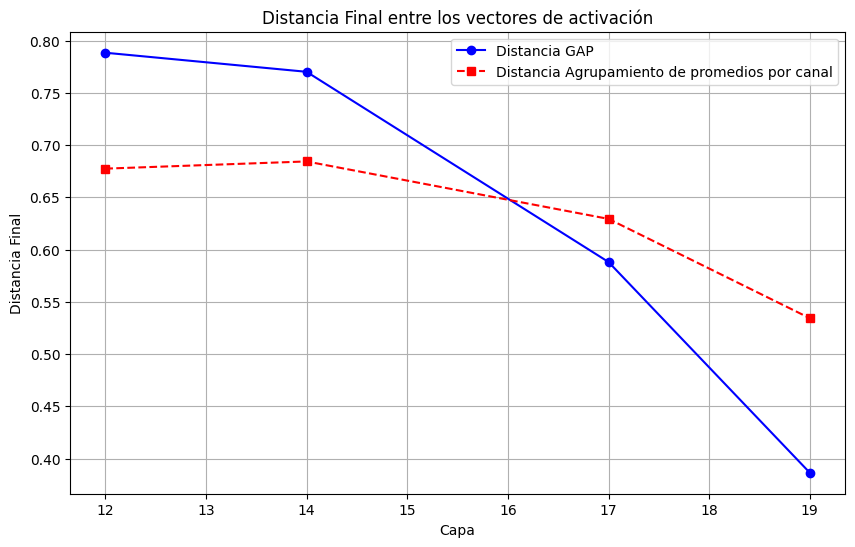

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_escala1_5.png


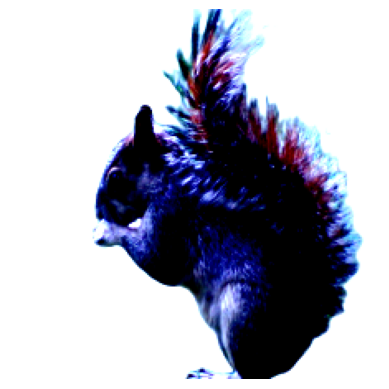

Usando la activación GAP 
para la capa 12, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 7.492
-entre clases de los vectores de dos imágenes distintas es: 10.844
-final entre los vectores usando activaciones GAP es: 0.691

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 12, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 6.774
-entre clases de vectores de dos imágenes diferentes es: 10.553
-final entre los vectores es: 0.642

Usando la activación GAP 
para la capa 14, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 4.601
-entre clases de los vectores de dos imágenes distintas es: 6.671
-final entre los vectores usando activaciones GAP es: 0.690

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 14, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 4.273
-entre clases de vectores de dos imágenes diferentes es: 5.732
-

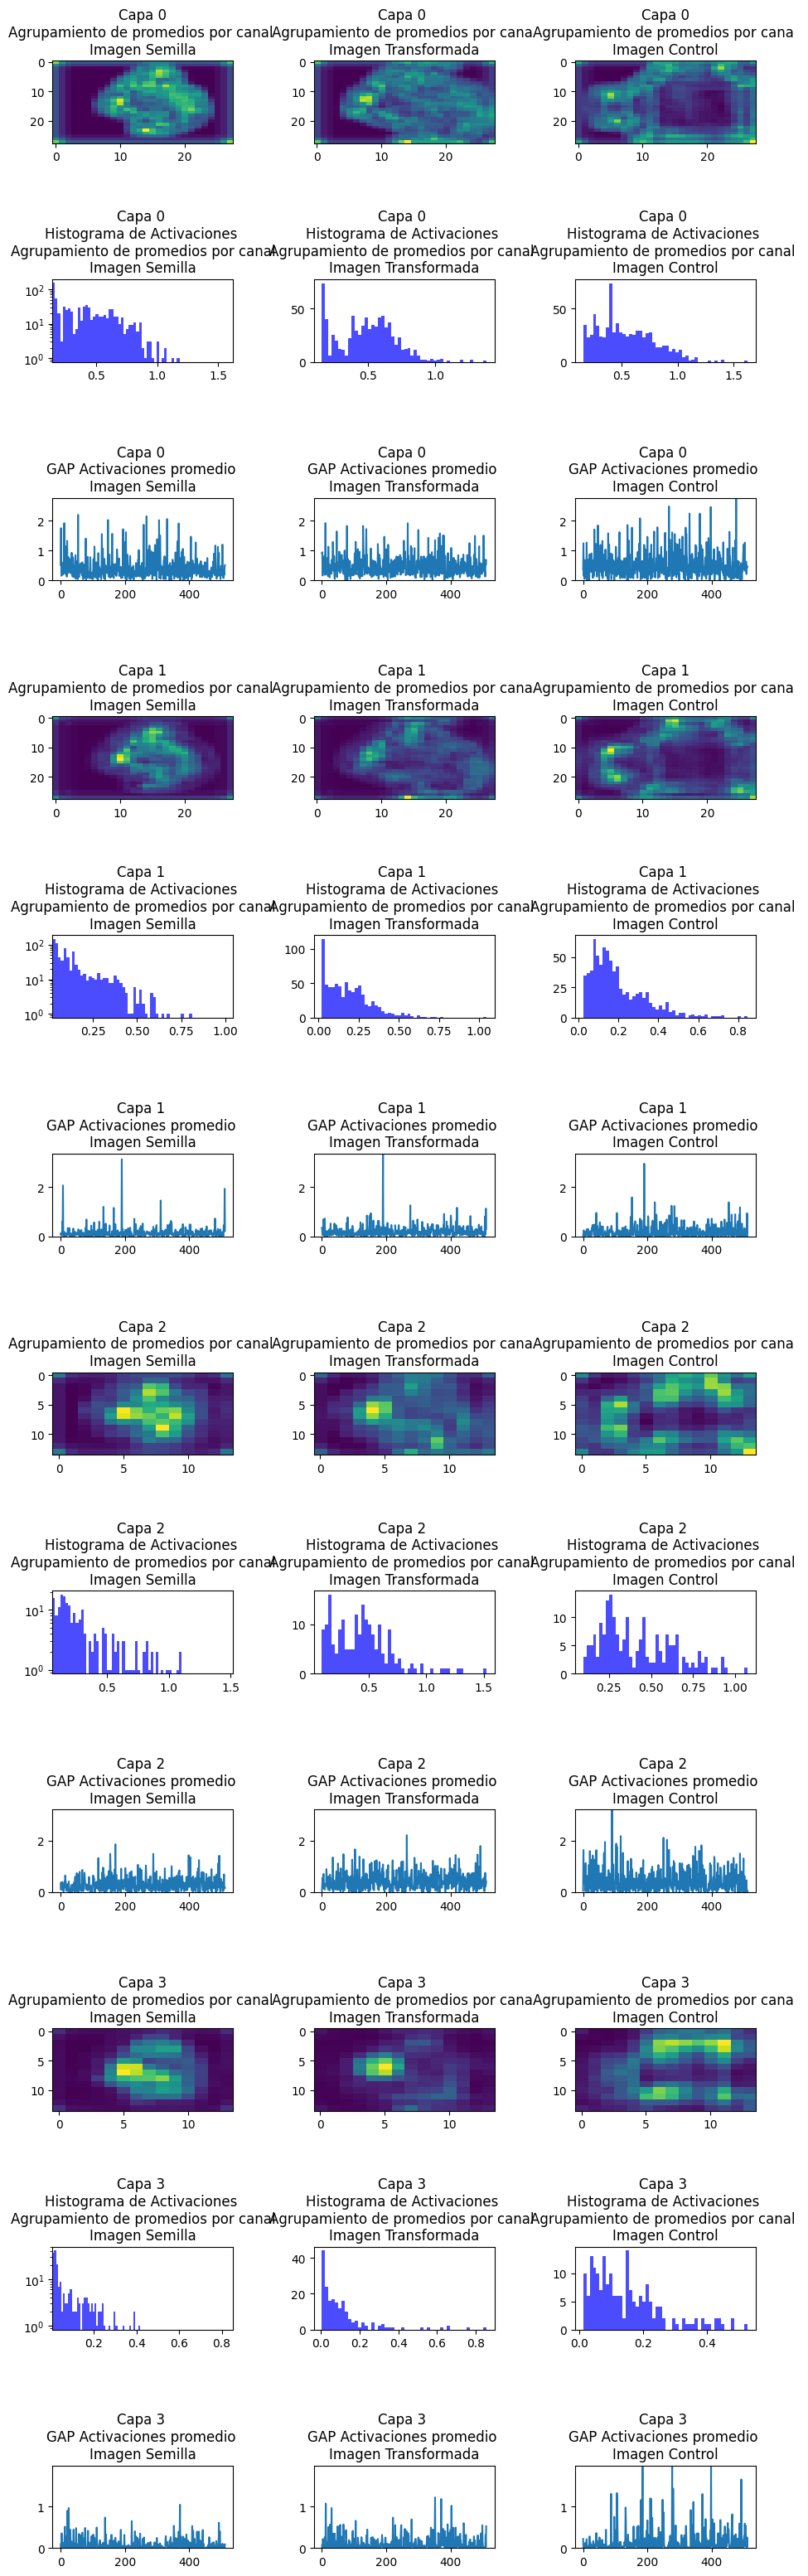

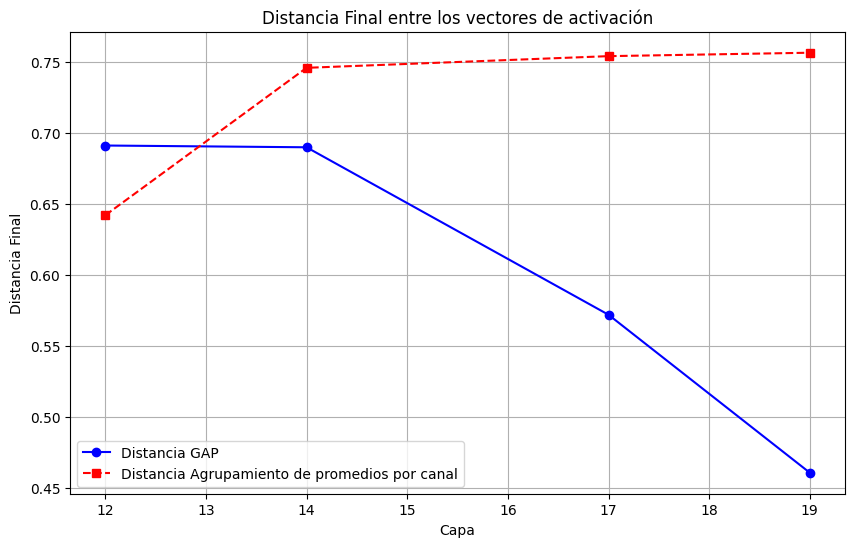

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_con_contexto.png


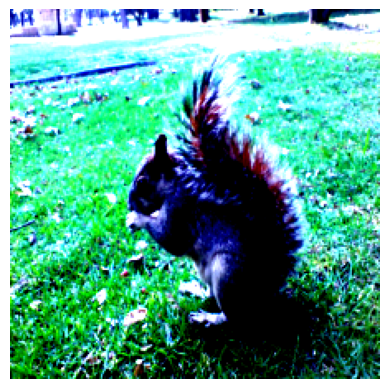

Usando la activación GAP 
para la capa 12, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 14.281
-entre clases de los vectores de dos imágenes distintas es: 10.844
-final entre los vectores usando activaciones GAP es: 1.317

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 12, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 6.946
-entre clases de vectores de dos imágenes diferentes es: 10.553
-final entre los vectores es: 0.658

Usando la activación GAP 
para la capa 14, la distancia Euclidiana
-entre los vectores de una imagen y su transformación es: 7.388
-entre clases de los vectores de dos imágenes distintas es: 6.671
-final entre los vectores usando activaciones GAP es: 1.107

Usando el cálculo de agrupamiento de promedios por canal 
para la capa 14, la distancia Euclidiana
-entre el vector de la imagen y su transformación es: 3.168
-entre clases de vectores de dos imágenes diferentes es: 5.732


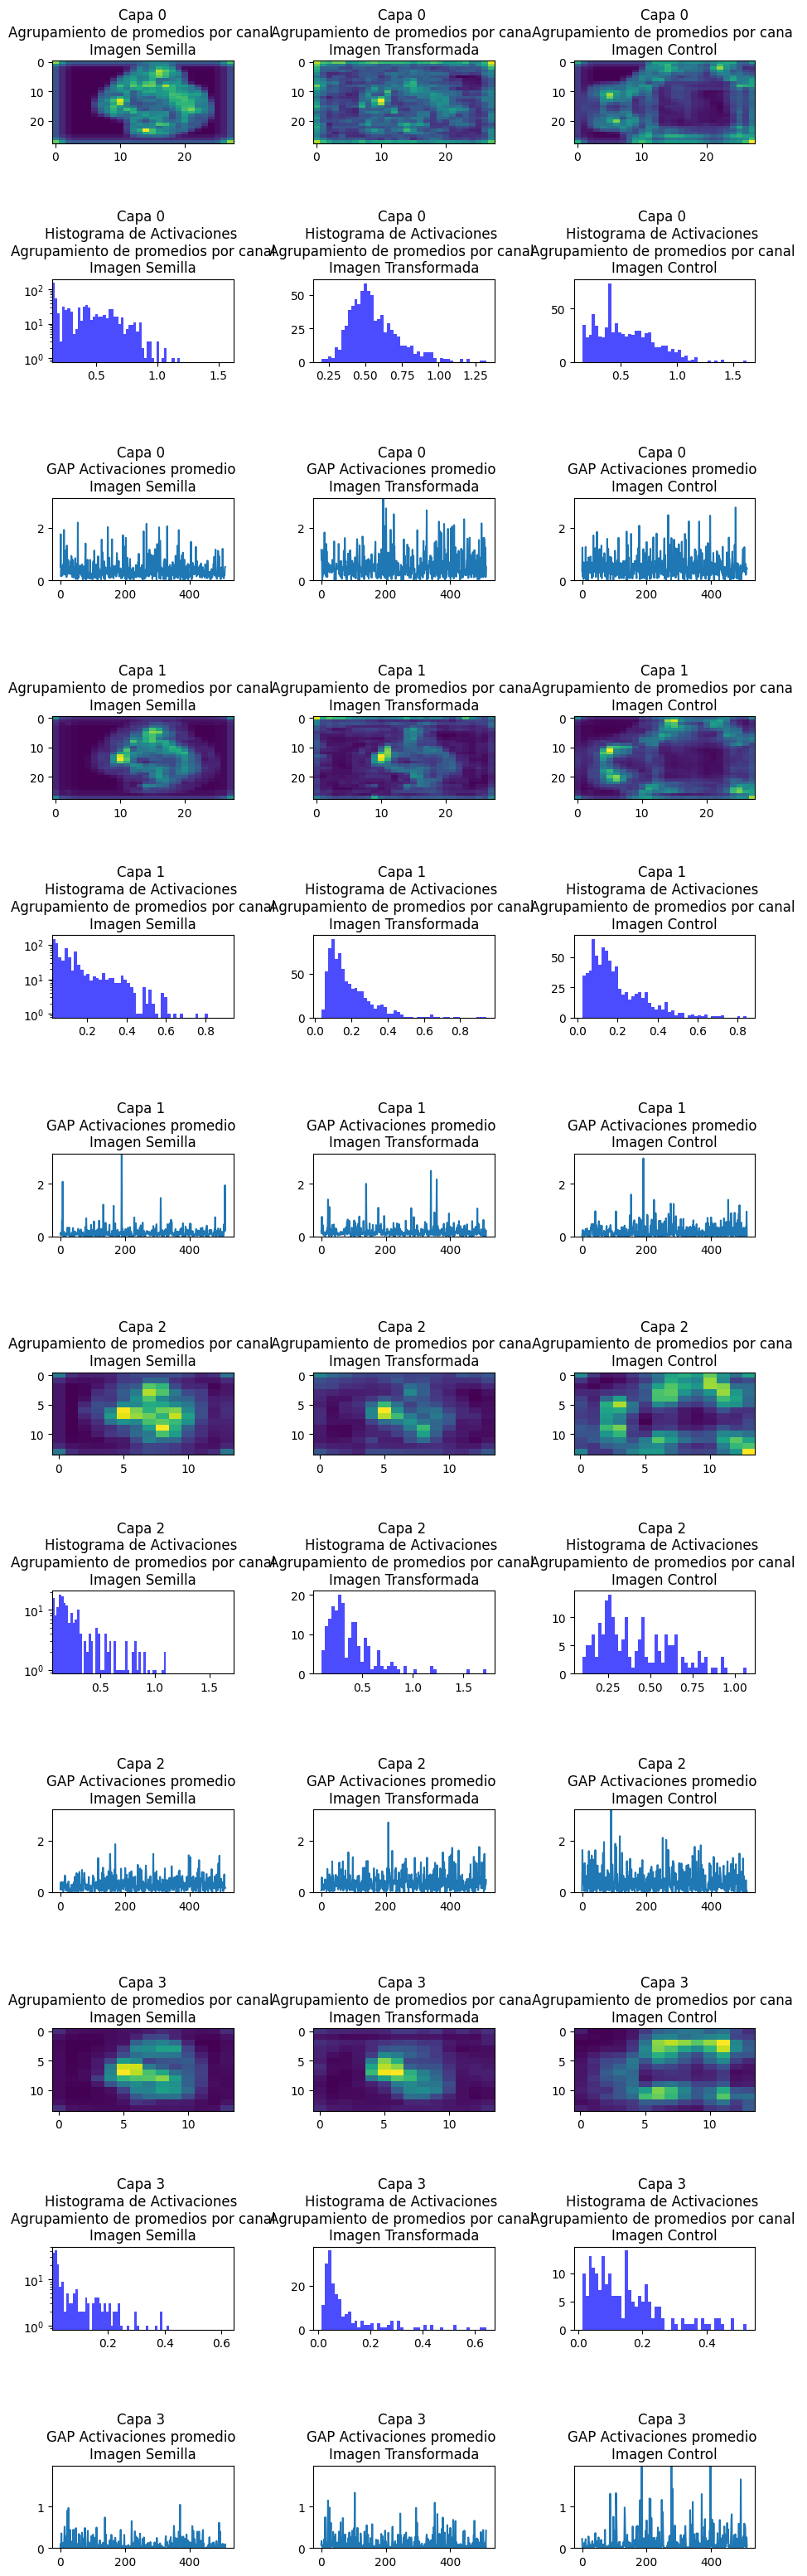

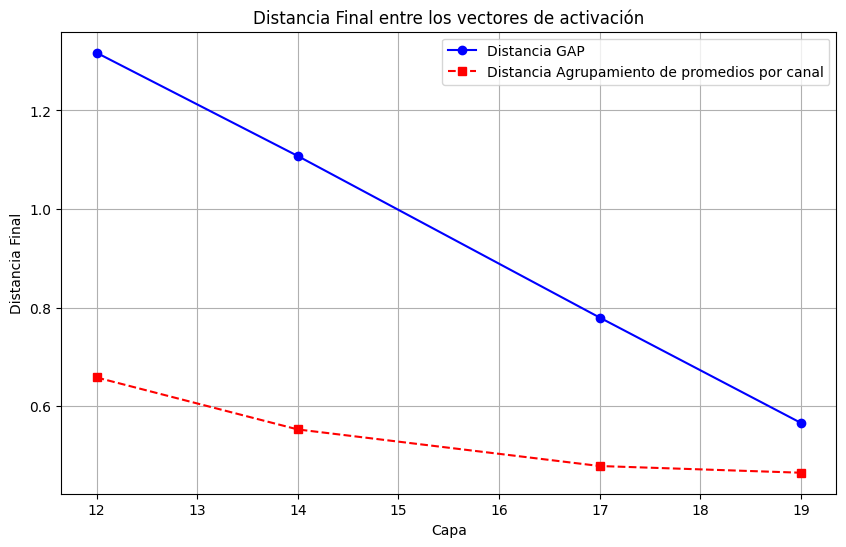

In [117]:
# Obtener las activaciones de imagen semilla
activaciones_semilla = get_activaciones(modelo.features, semilla_tensor, capas_a_visualizar)
activaciones_avg_canal_semilla = calcular_activaciones_promedio_canal(activaciones_semilla)
activaciones_gap_semilla = calcular_activaciones_promedio_gap(activaciones_semilla)

# Activaciones para la imagen de control
activaciones_ctrl = get_activaciones(modelo.features, control_tensor, capas_a_visualizar)
activaciones_avg_canal_ctrl = calcular_activaciones_promedio_canal(activaciones_ctrl)
activaciones_gap_ctrl = calcular_activaciones_promedio_gap(activaciones_ctrl)

# Activaciones para las transformaciones de las imagenes
for idx, img_tensor in enumerate(images_transformadas_tensores):
    print(f"Procesando imagen: {imagenes_transformadas_lista[idx]}")
    plt.imshow(img_tensor.squeeze(0).permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.show()

    # Obtener activaciones de la imagen actual
    activaciones_transform = get_activaciones(modelo.features, img_tensor, capas_a_visualizar)
    activaciones_avg_canal_transform = calcular_activaciones_promedio_canal(activaciones_transform)
    activaciones_gap_transform = calcular_activaciones_promedio_gap(activaciones_transform)

    # Plot feature maps and average activations
    gap_distancia_por_capa, avg_canal_distancias_por_capa = plot_mapas_avg_activaciones(
        activaciones_avg_canal_semilla, activaciones_avg_canal_transform, activaciones_avg_canal_ctrl,
        activaciones_gap_semilla, activaciones_gap_transform, activaciones_gap_ctrl,
        capas_a_visualizar
    )

    gap_distancias_lista_completa.append(gap_distancia_por_capa)
    avg_canal_distancias_lista_completa.append(avg_canal_distancias_por_capa)

## Análisis de Selectividad

En esta sección, realizamos un análisis de la selectividad del modelo capa por capa, transformación por transformación. Este análisis tiene como objetivo examinar la distribución de activaciones en diferentes capas, lo que proporciona información sobre cuán escasamente activadas están las neuronas en respuesta a diferentes entradas. Los hallazgos de este análisis se evaluarán más a fondo en el contexto del proyecto en general.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objecto_semilla.png


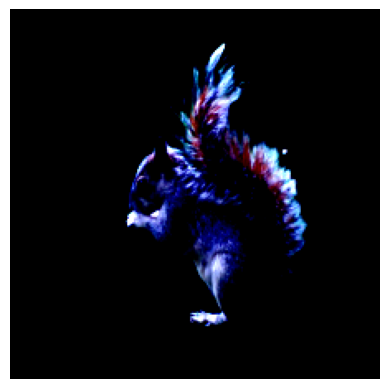

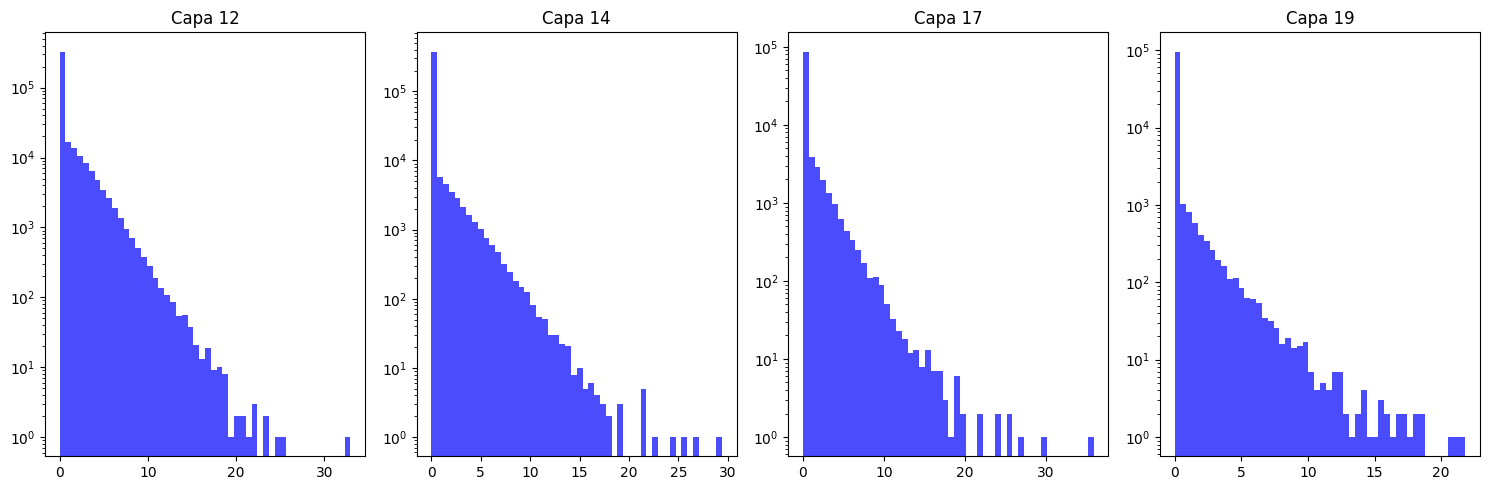

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_desplazado_derecha.png


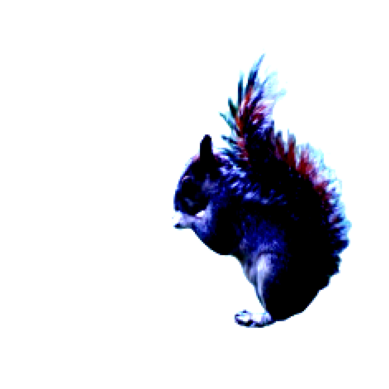

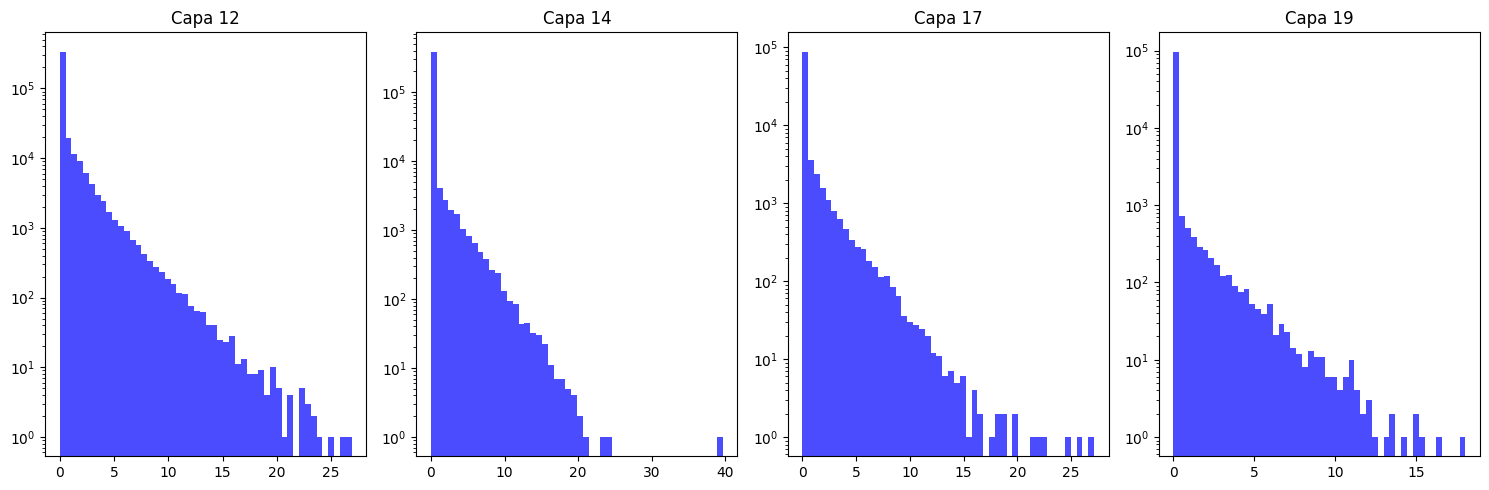

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_desplazado_izquierda.png


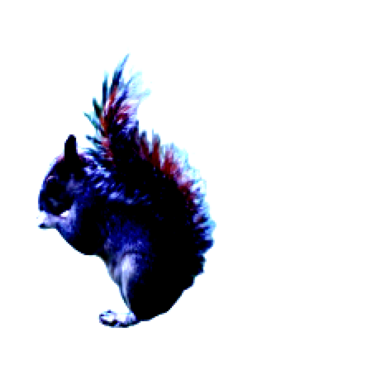

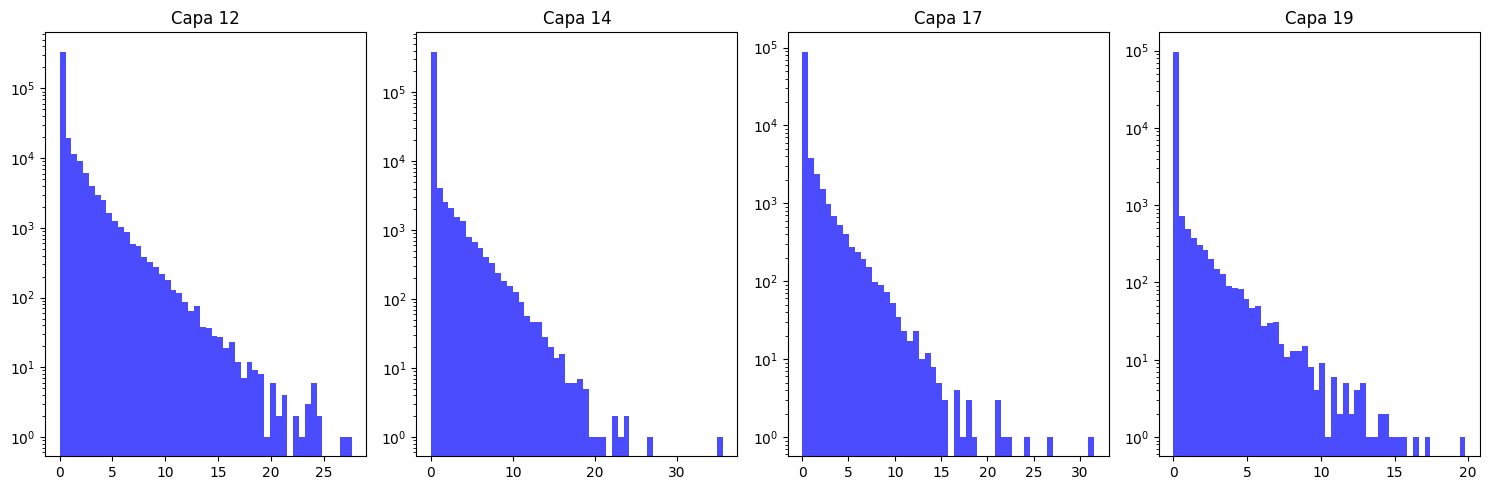

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_rotado_derecha.png


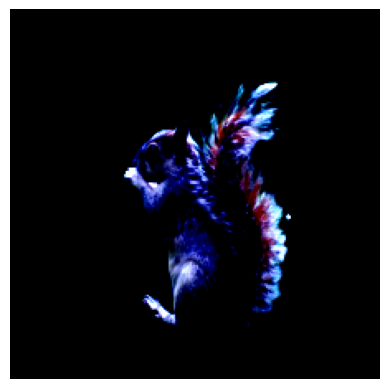

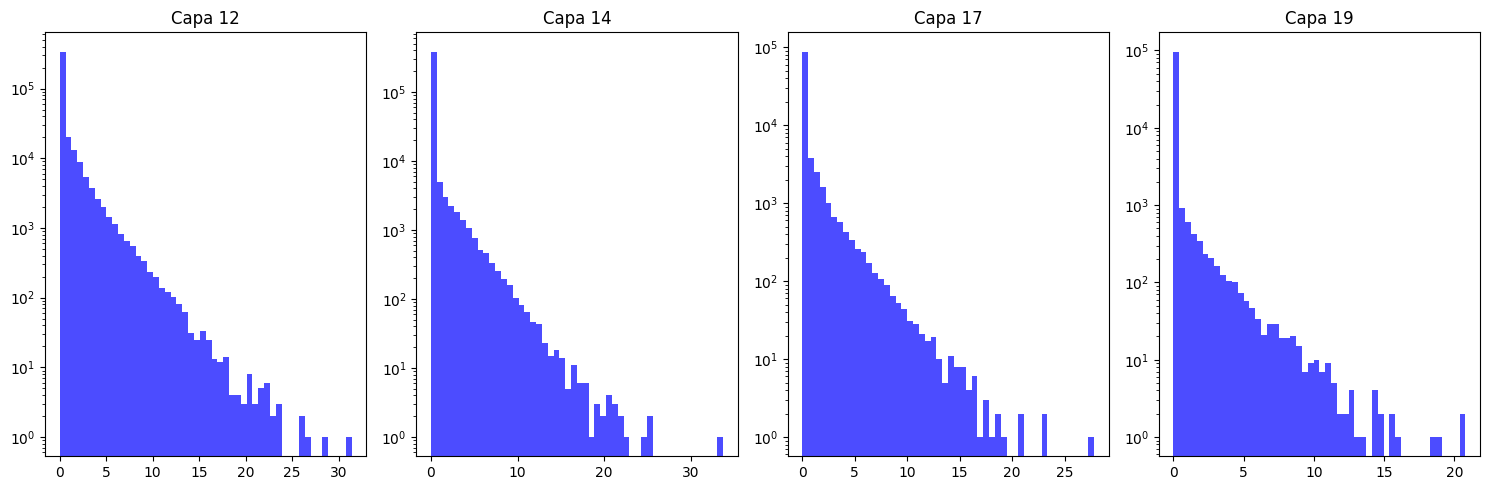

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_rotado_izquierda.png


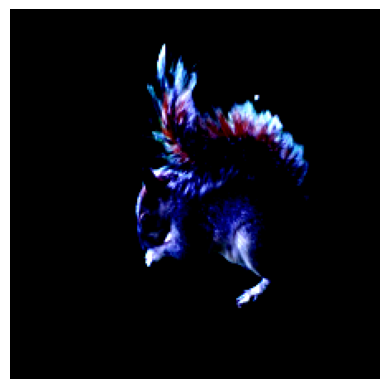

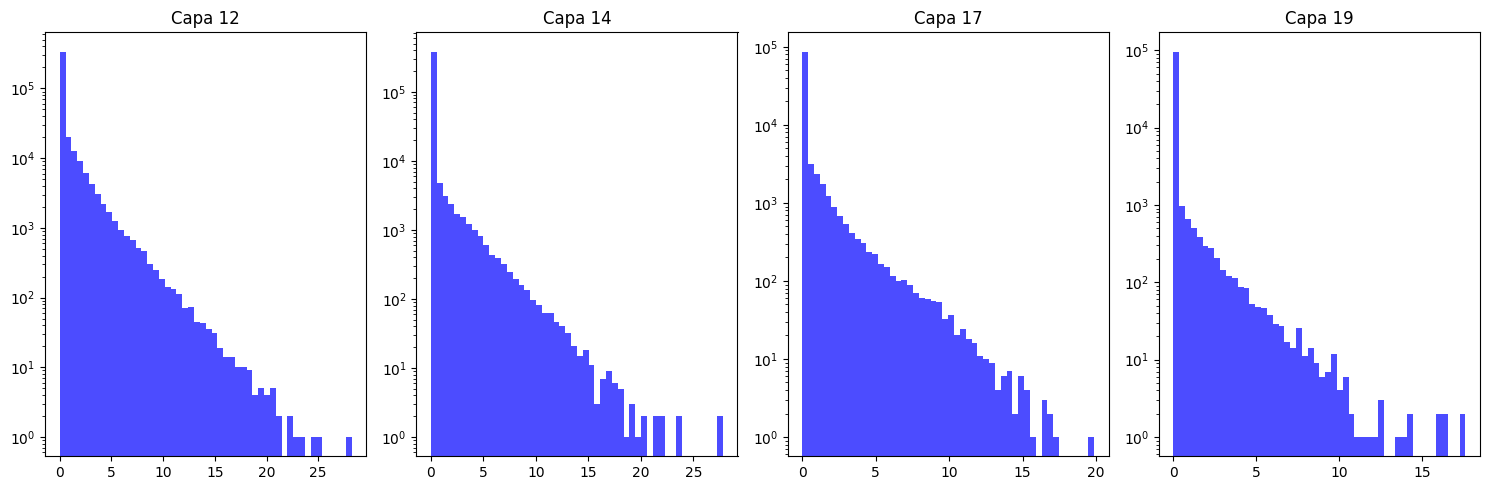

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_escala05.png


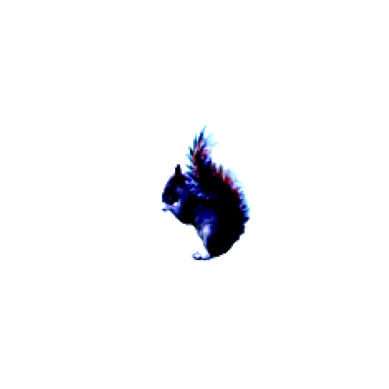

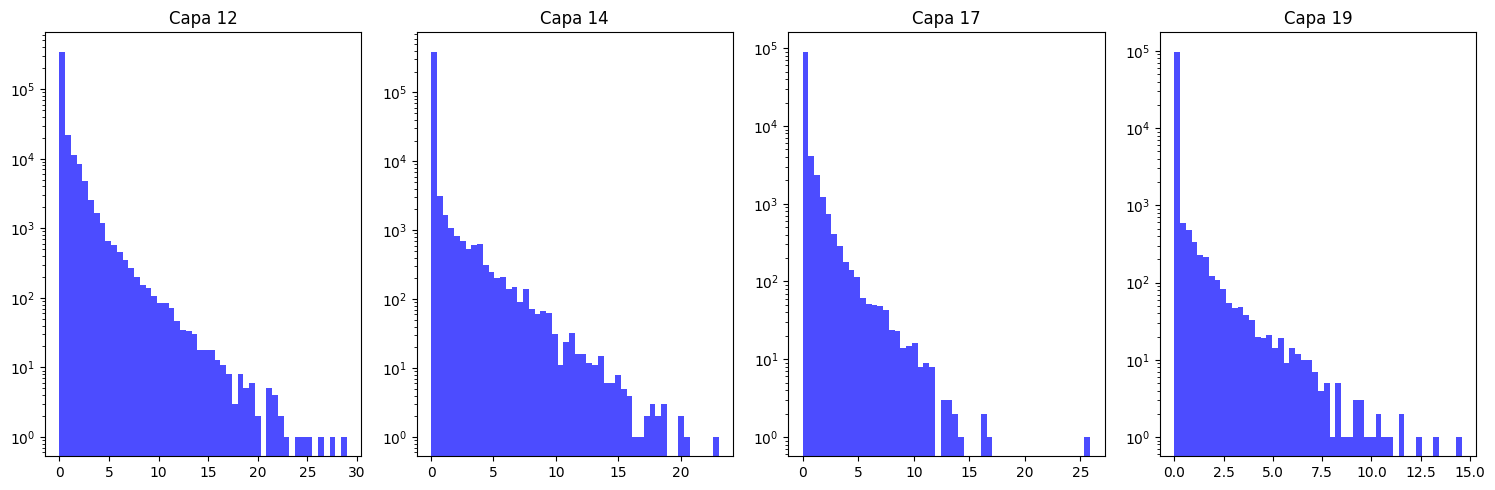

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_escala1_5.png


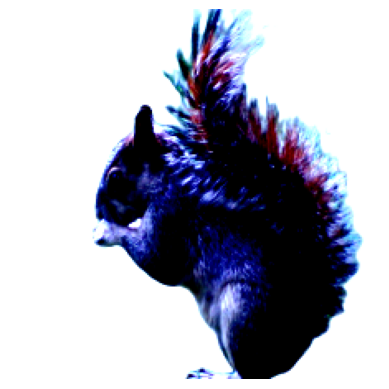

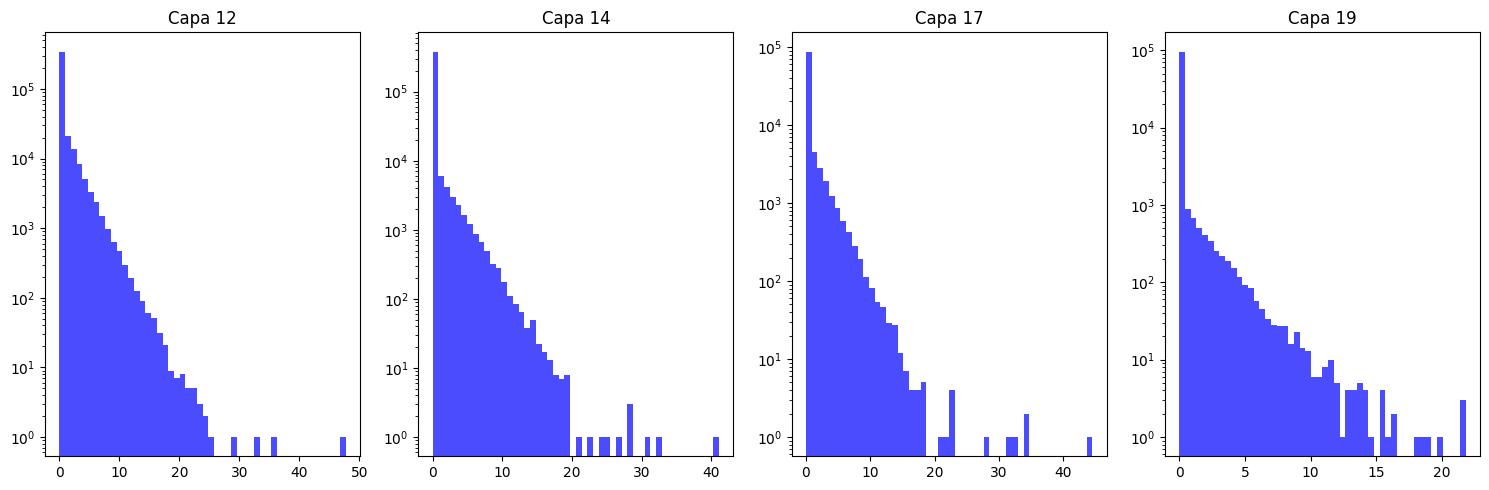

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Procesando imagen: objeto_con_contexto.png


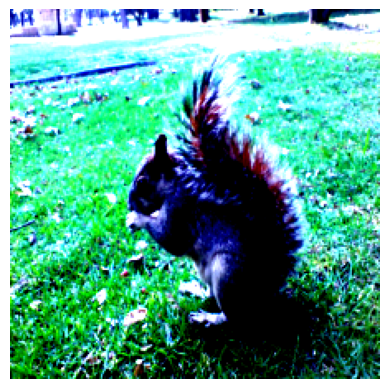

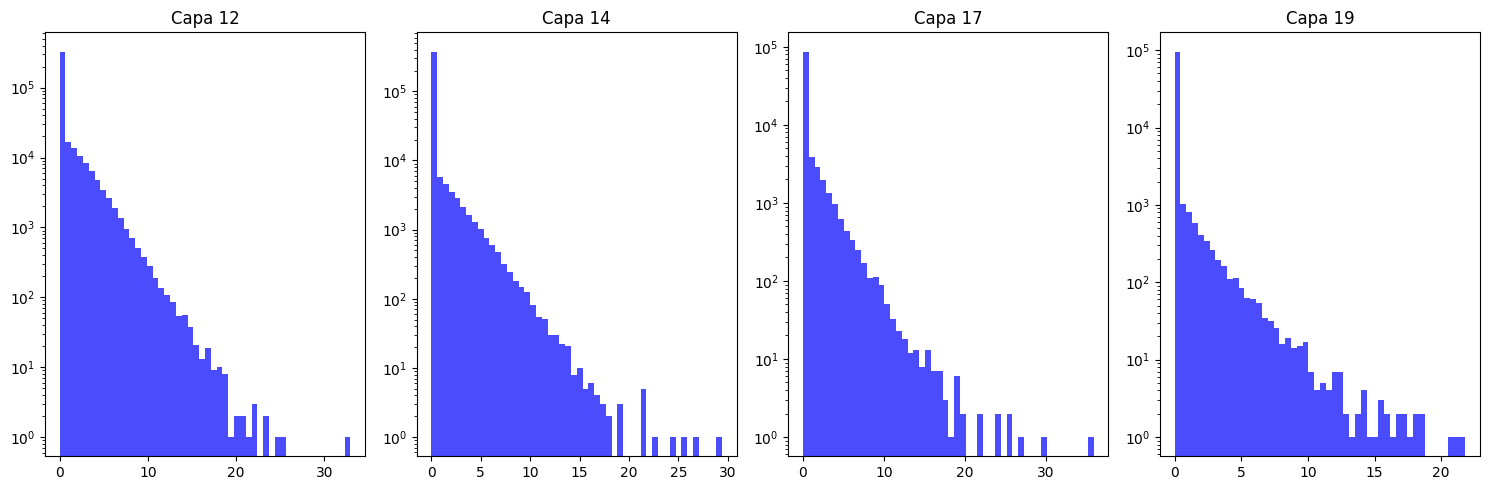

In [118]:
activaciones_totales = {}

activaciones_totales[f'objecto_semilla'] = activaciones_semilla

print(f"Procesando imagen: objecto_semilla.png")
plt.imshow(semilla_tensor.squeeze(0).permute(1, 2, 0).numpy())
plt.axis('off')
plt.show()

# Gráficar la selectividad para la imagen semilla
plot_selectividad(activaciones_transform, capas_a_visualizar)


# Gráficar la selectividad para las transformaciones de la imagen semilla
for idx, image_tensor in enumerate(images_transformadas_tensores):

    print(f"Procesando imagen: {imagenes_transformadas_lista[idx]}")
    plt.imshow(image_tensor.squeeze(0).permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.show()

    # Get activations for the current image tensor
    transform_activaciones = get_activaciones(modelo.features, image_tensor, capas_a_visualizar)
    activaciones_totales[f'transform_activaciones_{idx}'] = transform_activaciones

    # Plot sparseness for the transformed image activations
    plot_selectividad(transform_activaciones, capas_a_visualizar)

# Evaluación del projecto

En esta sección, evaluamos los resultados del experimento analizando las distancias promedio calculadas a partir de los análisis de invariancia y selectividad.

## Invarianza

Calculamos la distancia promedio GAP y la distancia promedio para el agrupamiento de promedios por canal en todas las transformaciones para cada capa. Esto proporciona información sobre cómo las transformaciones afectan las activaciones y si el modelo mantiene la invariancia en su proceso de extracción de características.

La evaluación se visualiza a través de dos gráficos: uno que representa la distancia promedio GAP y el otro que ilustra la distancia promedio para el agrupamiento de promedios por canal en las capas seleccionadas. Estas visualizaciones nos ayudan a comprender el comportamiento y la solidez del modelo al implementar varias transformaciones sobre una imagen.

In [119]:
# Calculo de promedio de distancias 
gap_distancia_total = np.mean(gap_distancias_lista_completa, axis=0)
avg_canales_distancia_total = np.mean(avg_canal_distancias_lista_completa, axis=0)

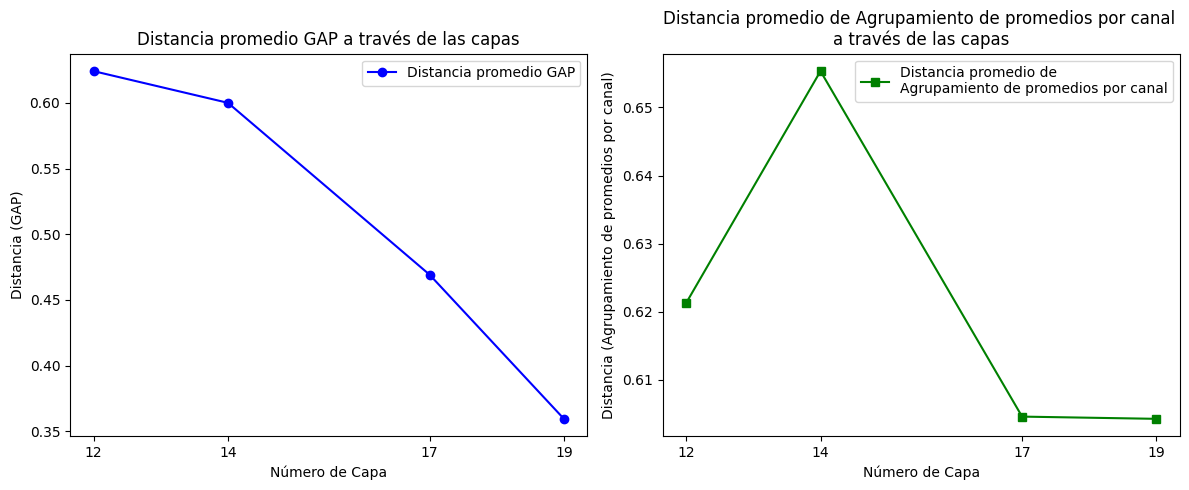

In [120]:
plt.figure(figsize=(12, 5))

# Grafico de promedio de distancias GAP
plt.subplot(1, 2, 1)
plt.plot(capas_a_visualizar, gap_distancia_total, label="Distancia promedio GAP", color="blue", marker='o')
plt.xticks(capas_a_visualizar) 
plt.xlabel("Número de Capa")
plt.ylabel("Distancia (GAP)")
plt.title("Distancia promedio GAP a través de las capas")
plt.legend()

# Grafico Distancia Agrupamiento de promedios por canal
plt.subplot(1, 2, 2)
plt.plot(capas_a_visualizar, avg_canales_distancia_total, label="Distancia promedio de \nAgrupamiento de promedios por canal", color="green", marker='s')
plt.xticks(capas_a_visualizar)
plt.xlabel("Número de Capa")
plt.ylabel("Distancia (Agrupamiento de promedios por canal)")
plt.title("Distancia promedio de Agrupamiento de promedios por canal \na través de las capas")
plt.legend()

plt.tight_layout()
plt.show()

## Selectividad

En esta sección calculamos la selectividad para cada transformación y acumulamos los resultados para todas las capas seleccionadas. Por último, calculamos la selectividad promedio por capa y visualizamos estos resultados mediante un gráfico, que nos ayuda a comprender cómo varían las representaciones de características del modelo en las diferentes capas.

Capa: 12, Promedio de selectividad: 0.898651
Capa: 14, Promedio de selectividad: 0.970610
Capa: 17, Promedio de selectividad: 0.923548
Capa: 19, Promedio de selectividad: 0.979517


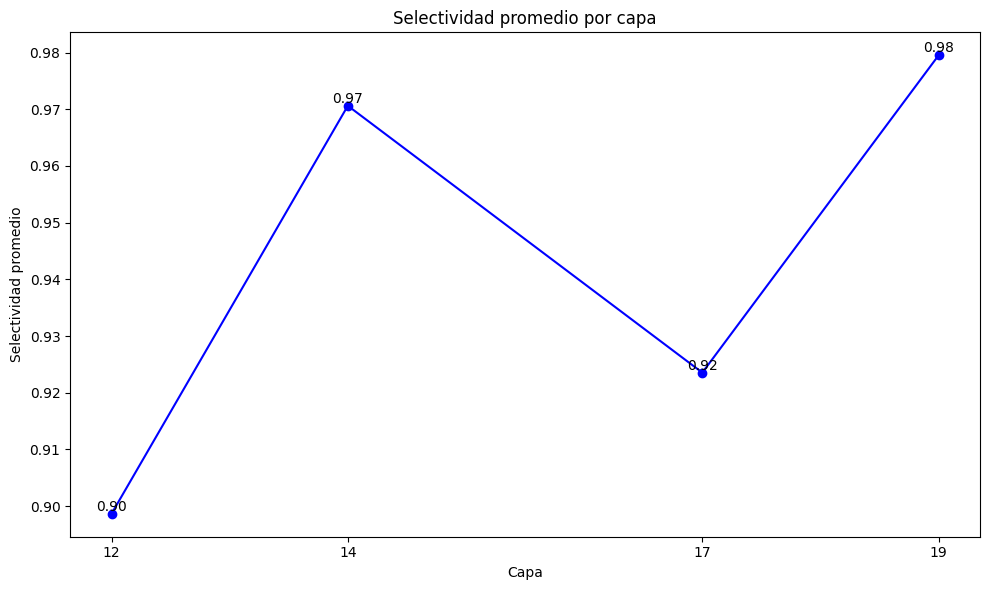

In [121]:
# Calcular selectividad para la imagen semilla y sus transformaciones
selectividad_resultados = []
for key, activaciones in activaciones_totales.items():
    for i, activacion in enumerate(activaciones):
        selectividad_resultados.append(computar_selectividad_para_activaciones(capas_a_visualizar[i], activacion))


# Inicializar un defaultdict para almacenar las sumas y ceuntas para cada capa
capa_selectividad_suma_cuenta = defaultdict(lambda: [0, 0])  # [suma, cuenta]

# Acumula sumas y cuentas para cada capa
for capa, selectividad in selectividad_resultados:
    capa_selectividad_suma_cuenta[capa][0] += np.sum(selectividad)  
    capa_selectividad_suma_cuenta[capa][1] += selectividad.size  # Incrementa la cuenta por el numero de valores

# Computa el promedio de selectividad por capa
avg_selectividad_por_capa = {
    capa: total_sum / count if count > 0 else 0
    for capa, (total_sum, count) in capa_selectividad_suma_cuenta.items()
}

# Mostrar el promedio de selectividad por capa
for capa, avg in avg_selectividad_por_capa.items():
    print(f"Capa: {capa}, Promedio de selectividad: {avg:.6f}")

# Extraer las claves y valores para gráficar
capas = list(avg_selectividad_por_capa.keys())
avg_selectividad = list(avg_selectividad_por_capa.values())

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(capas, avg_selectividad, marker='o', linestyle='-', color='b')

# Agregar etiquetas y titulo
plt.title('Selectividad promedio por capa')
plt.xlabel('Capa')
plt.ylabel('Selectividad promedio')
plt.xticks(capas) 

for i, value in enumerate(avg_selectividad):
    plt.text(capas[i], value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Conclusiones

Observamos que la invarianza disminuyó según se avanzaba en la jerarquía de la red, confirmando nuestra hipótesis de que las capas finales no representan características genéricas. Por otra parte, la selectividad aumentó inicialmente, luego descendió en capas intermedias y, finalmente, alcanzó su punto máximo en la última capa, contrastando con nuestra hipótesis inicial. Esta discrepancia pudo atribuirse a que únicamente se analizaron dos imágenes, resaltando la necesidad de estudiar un mayor conjunto de estímulos para obtener conclusiones más sólidas. 

# Referencias
<a id="1">[1]</a>
Rust, N. C., & DiCarlo, J. J. (2010). Selectivity and Tolerance (“Invariance”) Both Increase as Visual Information Propagates from Cortical Area V4 to IT. Journal of Neuroscience, 30(39), 12978–12995. https://doi.org/10.1523/jneurosci.0179-10.2010

<a id="2">[2]</a>
Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition. arXiv preprint arXiv:1409.1556.

<a id="3">[3]</a>
Vinje, W. E., & Gallant, J. L. (2000). Sparse Coding and Decorrelation in Primary Visual Cortex During Natural Vision. Science, 287(5456), 1273-1276.

<a id="4">[4]</a>
Rust, N. C., and J. J. DiCarlo. “Balanced Increases in Selectivity and Tolerance Produce Constant Sparseness Along the Ventral Visual Stream.” Journal of Neuroscience 32.30 (2012): 10170–10182.

# Fuentes
https://medium.com/coinmonks/how-to-get-images-from-imagenet-with-python-in-google-colaboratory-aeef5c1c45e5